# 🧠 Pediatric Neuro-Oncology Surgical Planning Agent — Colab（v3）

NVIDIA Nemotron 3 Super 核心推理 + Cosmos Nemotron 34B 影像（VLM）

**v3 修正:** 影像 VLM 預設改成有免費雲端端點的 `cosmos-nemotron-34b`,並加逾時保護,不會再卡死。

⚠️ key 用 getpass 不寫死;舊 key 請先到 build.nvidia.com 作廢。

## Step 1 — 上傳專案 zip（用最新的 v3 zip）

In [15]:
from google.colab import files
uploaded = files.upload()

Saving pediatric-neuro-oncology-agent.zip to pediatric-neuro-oncology-agent.zip


## Step 2 — 自動找 zip 並解壓

In [16]:
import glob, zipfile, os
zips = glob.glob('/content/*pediatric-neuro-oncology-agent*.zip')
assert zips, "找不到 zip,請確認 Step 1 上傳成功"
print("解壓:", zips[0])
with zipfile.ZipFile(zips[0]) as z: z.extractall('/content')
os.chdir('/content/pediatric-neuro-oncology-agent')
print("✅ 已進入:", os.getcwd())

解壓: /content/pediatric-neuro-oncology-agent (2) (1).zip
✅ 已進入: /content/pediatric-neuro-oncology-agent


In [17]:
# ============================================================
# Step 0 / Step 3 前面請先跑：NumPy 1.x compatibility bootstrap
# 請放在任何 import numpy / pandas / sklearn / scipy / monai 之前
# ============================================================

import os
import sys
import subprocess
import importlib.util

def _get_numpy_version():
    try:
        import numpy as np
        return np.__version__
    except Exception:
        return None

np_version = _get_numpy_version()
print("Current numpy =", np_version)

needs_install = False

if np_version is None:
    needs_install = True
else:
    major = int(np_version.split(".")[0])
    if major >= 2:
        needs_install = True

if needs_install:
    print("Detected NumPy 2.x or missing NumPy.")
    print("Installing NumPy 1.26.4 for drug-ranking artifact compatibility...")

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--force-reinstall",
        "numpy==1.26.4",
        "pandas==2.2.2",
        "scipy==1.13.1",
        "scikit-learn==1.5.2"
    ])

    print("✅ Downgrade completed.")
    print("🔁 Restarting runtime automatically. After restart, rerun all cells from Step 1.")

    # Colab/Jupyter kernel restart
    os.kill(os.getpid(), 9)

else:
    print("✅ NumPy version is compatible:", np_version)

Current numpy = 1.26.4
✅ NumPy version is compatible: 1.26.4


## Step 3 — 安裝套件

In [18]:
!!pip install -q \
  openai \
  python-dotenv \
  pillow \
  pydicom \
  nibabel \
  scipy==1.13.1 \
  scikit-learn==1.5.2 \
  pandas==2.2.2 \
  matplotlib \
  ipywidgets \
  monai

print("✅ packages installed")

✅ packages installed


## Step 4 — 安全輸入 API key（VLM 已改成 Cosmos）

In [19]:
import numpy as np
print(np.__version__)

1.26.4


In [20]:
import os, getpass
os.environ["NVIDIA_API_KEY"]    = getpass.getpass("貼上你的新 nvapi- key（不會顯示）: ")
os.environ["NEMOTRON_MODEL"]    = "nvidia/nemotron-3-super-120b-a12b"   # 核心推理
os.environ["NVIDIA_VLM_MODEL"] = "nvidia/llama-3.1-nemotron-nano-vl-8b-v1"          # 影像 VLM（免費雲端端點）
os.environ["NVIDIA_VLM_TIMEOUT"]= "45"                                  # VLM 逾時保護
print("✅ 環境變數已設定")

貼上你的新 nvapi- key（不會顯示）: ··········
✅ 環境變數已設定


In [21]:
import os, base64
from openai import OpenAI
client = OpenAI(api_key=os.environ["NVIDIA_API_KEY"],
                base_url="https://integrate.api.nvidia.com/v1", timeout=40)
img_file = "T1.jpg"   # 你的圖
with open(img_file,"rb") as f:
    b64 = base64.b64encode(f.read()).decode()

# Nemotron 家族影像模型優先,接著才是 Llama 備案
candidates = [
    "nvidia/llama-3.1-nemotron-nano-vl-8b-v1",   # ← Nemotron 家族,優先
    "meta/llama-3.2-11b-vision-instruct",         # ← 已驗證能用的備案
]
for model in candidates:
    print(f"\n── 測試 {model} ──")
    try:
        r = client.chat.completions.create(
            model=model,
            messages=[{"role":"user","content":[
                {"type":"text","text":"Describe this brain image in one sentence."},
                {"type":"image_url","image_url":{"url":f"data:image/jpeg;base64,{b64}"}},
            ]}],
            max_tokens=120,
        )
        print("✅ 能用! 回應:", r.choices[0].message.content[:200])
        print(f"   → 填進 Step 4: {model}")
        break
    except Exception as e:
        print("❌", type(e).__name__, "|", str(e)[:120])


── 測試 nvidia/llama-3.1-nemotron-nano-vl-8b-v1 ──
❌ PermissionDeniedError | Error code: 403 - {'status': 403, 'title': 'Forbidden', 'detail': 'Authorization failed'}

── 測試 meta/llama-3.2-11b-vision-instruct ──
❌ PermissionDeniedError | Error code: 403 - {'status': 403, 'title': 'Forbidden', 'detail': 'Authorization failed'}


## Step 5 — 文字核心測試（必跑）
看 `Reasoning mode:` 應為 **Nemotron live**。

In [22]:
import os
os.chdir('/content/pediatric-neuro-oncology-agent')
!python run_demo.py sample_cases/case_003_diffuse_midline_glioma.txt


=== Running autonomous agent on case_003_diffuse_midline_glioma.txt ===
Reasoning mode: Nemotron live (nvidia/nemotron-3-super-120b-a12b)

--- AGENT TRACE ---
  • De-identification: removed nothing
  • Completeness: missing nothing critical
  • Retrieved 5 evidence chunks
  • Nemotron reasoning generated (Nemotron live (nvidia/nemotron-3-super-120b-a12b))
  • Matched 4 candidate trial(s)
  • Guardrails: passed=True, blocked=0, flagged=['basilar artery', 'brainstem', 'pons']

✅ Report written to: /content/pediatric-neuro-oncology-agent/outputs/case_003_diffuse_midline_glioma_20260525_173057.md

# Pediatric Neuro-Oncology — Preoperative MDT Support Report
*Generated 2026-05-25 17:30 · Reasoning mode: Nemotron live (nvidia/nemotron-3-super-120b-a12b)*

## 1. De-identified Case Summary
```
7-year-old child.
MRI: diffuse expansile T2-hyperintense lesion infiltrating the pons, encasing the basilar artery, minimal enhancement.
Symptoms: double vision, facial asymmetry, unsteady gait, rapid p

## Step 6 —（VLM 通了再跑）單張影像走完整流程
會自動把影像搬進專案資料夾。

In [23]:
import os, shutil
os.chdir('/content/pediatric-neuro-oncology-agent')
from google.colab import files
up = files.upload()
fname = next(iter(up.keys()))
base = os.path.basename(fname)
if os.path.exists(fname) and os.path.abspath(fname)!=os.path.join(os.getcwd(),base):
    shutil.move(fname, base)
print("影像:", base)
!python run_demo.py sample_cases/case_003_diffuse_midline_glioma.txt --image "{base}"

Saving T1W1.jpg to T1W1.jpg
影像: T1W1.jpg

=== Running autonomous agent on case_003_diffuse_midline_glioma.txt ===
Reasoning mode: Nemotron live (nvidia/nemotron-3-super-120b-a12b)

/content/pediatric-neuro-oncology-agent/agent.py:162: RuntimeWarning: 送出影像到雲端 VLM 前，請確認已去識別化：DICOM metadata、影像邊框燒錄姓名/病歷號/日期等個資需移除。此模組會重新編碼影像以移除一般檔案 metadata，但無法保證移除燒錄在像素內的文字。
  single = describe_image(paths[0])
Image analysis failed; falling back to manual imaging_description.
Traceback (most recent call last):
  File "/content/pediatric-neuro-oncology-agent/image_analysis.py", line 179, in describe_image
    raw_text = _call_nvidia_vlm(
               ^^^^^^^^^^^^^^^^^
  File "/content/pediatric-neuro-oncology-agent/image_analysis.py", line 319, in _call_nvidia_vlm
    response = client.chat.completions.create(**kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_utils/_utils.py", line 287, in wrapper
    return func(*args, **kwargs)
      

## Step 7 —（方向②）多序列 MRI
一次選多張,檔名含 t1/t2/flair/dwi 會自動辨識序列。

In [24]:
import os, shutil
os.chdir('/content/pediatric-neuro-oncology-agent')
from google.colab import files
up = files.upload()
moved=[]
for fname in up.keys():
    base=os.path.basename(fname)
    if os.path.exists(fname) and os.path.abspath(fname)!=os.path.join(os.getcwd(),base):
        shutil.move(fname, base)
    moved.append(base)
paths=" ".join(f'"{m}"' for m in moved)
print("多序列:", moved)
!python run_demo.py sample_cases/case_003_diffuse_midline_glioma.txt --images {paths}

Saving DWI.jpg to DWI (1).jpg
Saving FLAIR.jpg to FLAIR (2).jpg
Saving SWI.jpg to SWI.jpg
Saving T1W1.jpg to T1W1 (1).jpg
Saving T2WI.jpg to T2WI.jpg
多序列: ['DWI (1).jpg', 'FLAIR (2).jpg', 'SWI.jpg', 'T1W1 (1).jpg', 'T2WI.jpg']

=== Running autonomous agent on case_003_diffuse_midline_glioma.txt ===
Reasoning mode: Nemotron live (nvidia/nemotron-3-super-120b-a12b)

/content/pediatric-neuro-oncology-agent/image_multimodal.py:61: RuntimeWarning: 送出影像到雲端 VLM 前，請確認已去識別化：DICOM metadata、影像邊框燒錄姓名/病歷號/日期等個資需移除。此模組會重新編碼影像以移除一般檔案 metadata，但無法保證移除燒錄在像素內的文字。
  res = describe_image(path)               # 重用 GPT 的單張分析
Image analysis failed; falling back to manual imaging_description.
Traceback (most recent call last):
  File "/content/pediatric-neuro-oncology-agent/image_analysis.py", line 179, in describe_image
    raw_text = _call_nvidia_vlm(
               ^^^^^^^^^^^^^^^^^
  File "/content/pediatric-neuro-oncology-agent/image_analysis.py", line 319, in _call_nvidia_vlm
    response = client.chat.c

## Step 8 — 看最新完整報告

In [25]:
import glob, os
os.chdir('/content/pediatric-neuro-oncology-agent')
mds=glob.glob('outputs/*.md'); assert mds,"先跑 Step 5"
latest=max(mds,key=os.path.getmtime)
print("報告:",latest,chr(10),"="*60)
print(open(latest,encoding='utf-8').read())

報告: outputs/case_003_diffuse_midline_glioma_20260525_173558.md 
# Pediatric Neuro-Oncology — Preoperative MDT Support Report
*Generated 2026-05-25 17:35 · Reasoning mode: Nemotron live (nvidia/nemotron-3-super-120b-a12b)*

## 1. De-identified Case Summary
```
7-year-old child.
MRI: diffuse expansile T2-hyperintense lesion infiltrating the pons, encasing the basilar artery, minimal enhancement.
Symptoms: double vision, facial asymmetry, unsteady gait, rapid progression over weeks.
Tumor location: pons (brainstem).
Molecular markers: H3 K27M mutation positive.
Pathology: diffuse midline glioma, H3 K27-altered (WHO grade 4).
Previous treatment: none.
Family's main question: Can surgery remove this tumor?
```
> 🔒 No PHI detected.

## 1b. AI-Assisted Imaging Observations
> 🖼️ Image analysis status: **error** (non-diagnostic; radiologist confirmation required)
- [DWI] 影像辨識失敗；主流程應保留醫師手動輸入的 imaging_description 作為 fallback。
- [FLAIR] 影像辨識失敗；主流程應保留醫師手動輸入的 imaging_description 作為 fallback。
- [SWI]

## Step 9 —（可選）展示長程代理自主迴圈

In [26]:
import os
os.chdir('/content/pediatric-neuro-oncology-agent')
!python watcher.py --once
!cat logs/autonomous_runs.log

[2026-05-25T17:36:12.708279] autonomous refresh: +0 new, 8 chunks indexed
2026-05-25T15:22:40.819244 CASE_RUN mode=Nemotron live (nvidia/nemotron-3-super-120b-a12b) missing=0 trials=4 guardrail_pass=True
2026-05-25T15:22:58.401559 CASE_RUN mode=Nemotron live (nvidia/nemotron-3-super-120b-a12b) missing=0 trials=4 guardrail_pass=True
2026-05-25T15:23:18.587109 CASE_RUN mode=Nemotron live (nvidia/nemotron-3-super-120b-a12b) missing=0 trials=4 guardrail_pass=True
2026-05-25T15:24:29.127696 KB_REFRESH new_items=0 indexed_chunks=8
2026-05-25T15:53:34.892516 CASE_RUN mode=Nemotron live (nvidia/nemotron-3-super-120b-a12b) missing=0 trials=4 guardrail_pass=True
2026-05-25T17:30:57.432240 CASE_RUN mode=Nemotron live (nvidia/nemotron-3-super-120b-a12b) missing=0 trials=4 guardrail_pass=True
2026-05-25T17:35:23.826560 CASE_RUN mode=Nemotron live (nvidia/nemotron-3-super-120b-a12b) missing=0 trials=4 guardrail_pass=True
2026-05-25T17:35:58.031259 CASE_RUN mode=Nemotron live (nvidia/nemotron-3-super

## Step 10 — 加入 architecture 圖與藥物篩選系統

這一段會做三件事：

1. 將 `腦瘤架構圖.jpg` 放入 `assets/` 與 `outputs/`，並可附到最終 MDT 報告。
2. 將 `06_drug_ranking_widget.ipynb` 的核心功能包成可重用的 `drug_ranking_adapter.py`。
3. 在病例層級產生 preclinical drug ranking appendix，並保留安全聲明：**不是治療建議，只能作為研究／MDT 討論輔助**。

In [27]:
%%writefile drug_ranking_adapter.py
# -*- coding: utf-8 -*-
"""
drug_ranking_adapter.py

Adapter layer to plug `06_drug_ranking_widget.ipynb` into the
Pediatric Neuro-Oncology Surgical Planning Agent.

It keeps the drug system optional:
- If artifacts are available, it produces preclinical drug sensitivity rankings.
- If artifacts / GitHub / intermediates are unavailable, it returns a safe fallback.
- Output is explicitly NOT a treatment recommendation.

Expected external repo from the original widget notebook:
    https://github.com/otonifrio2812/pediatric-bt-drug-prediction
Expected API in that repo:
    from src.drug_ranking import load_artifacts, list_cells_by_cancer_type, predict_drug_ranking
"""

from __future__ import annotations

import os
import sys
import json
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple


DRUG_RANKING_DISCLAIMER = (
    "AI preclinical drug-ranking module for research triage only. "
    "It is not a treatment recommendation, prescription, or substitute for "
    "pediatric neuro-oncology / pharmacy / molecular tumor board review."
)

DEFAULT_GITHUB_USER = "otonifrio2812"
DEFAULT_REPO_NAME = "pediatric-bt-drug-prediction"
DEFAULT_RELEASE_TAG = "v1.0.1"


def _run(cmd: List[str], cwd: Optional[str] = None) -> None:
    """Run a shell command safely from Python."""
    print(" ".join(cmd))
    subprocess.check_call(cmd, cwd=cwd)


def setup_drug_ranking_repo(
    workdir: str = "/content",
    github_user: str = DEFAULT_GITHUB_USER,
    repo_name: str = DEFAULT_REPO_NAME,
    release_tag: str = DEFAULT_RELEASE_TAG,
    install_requirements: bool = True,
) -> str:
    """
    Colab helper:
    - clone pediatric-bt-drug-prediction
    - install its requirements
    - download intermediates.zip from GitHub Release

    Returns repo_dir.

    NOTE:
    The original widget notebook used NumPy<2 for pickle compatibility.
    If Colab already loaded NumPy 2.x, restart runtime after downgrading.
    """
    workdir_path = Path(workdir)
    repo_dir = workdir_path / repo_name
    workdir_path.mkdir(parents=True, exist_ok=True)

    if not repo_dir.exists():
        _run([
            "git", "clone", "-q",
            f"https://github.com/{github_user}/{repo_name}.git",
            str(repo_dir),
        ])

    if install_requirements and (repo_dir / "requirements.txt").exists():
        _run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], cwd=str(repo_dir))

    intermediates_dir = repo_dir / "intermediates"
    pkl_path = intermediates_dir / "stage6_ensemble_models.pkl"
    if not pkl_path.exists():
        intermediates_dir.mkdir(parents=True, exist_ok=True)
        release_url = (
            f"https://github.com/{github_user}/{repo_name}/"
            f"releases/download/{release_tag}/intermediates.zip"
        )
        zip_path = repo_dir / "intermediates.zip"
        _run(["wget", "-q", release_url, "-O", str(zip_path)])
        _run(["unzip", "-q", str(zip_path), "-d", str(intermediates_dir)])

    if str(repo_dir) not in sys.path:
        sys.path.insert(0, str(repo_dir))

    return str(repo_dir)


def ensure_numpy_pickle_compatibility() -> Dict[str, Any]:
    """
    Helper for Colab before loading the external pickle artifacts.
    Returns a dict; if needs_restart=True, restart runtime then run cells again.
    """
    import numpy as np

    version = np.__version__
    out = {
        "numpy_version": version,
        "needs_restart": False,
        "message": f"numpy={version} is compatible.",
    }

    if version.startswith("2"):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numpy<2.0", "scipy<1.13"])
        out["needs_restart"] = True
        out["message"] = (
            f"Current numpy={version}. Downgraded to numpy<2.0. "
            "Please restart runtime/session, then rerun the setup cell."
        )
    return out


def _import_drug_api(repo_dir: Optional[str] = None):
    """Import the external repo's drug-ranking API."""
    if repo_dir and repo_dir not in sys.path:
        sys.path.insert(0, repo_dir)
    try:
        from src.drug_ranking import load_artifacts, list_cells_by_cancer_type, predict_drug_ranking
        return load_artifacts, list_cells_by_cancer_type, predict_drug_ranking
    except Exception as exc:
        raise ImportError(
            "Could not import src.drug_ranking. Run setup_drug_ranking_repo() first "
            "or execute the original 06_drug_ranking_widget.ipynb setup cells."
        ) from exc


def load_drug_ranking_artifacts(
    repo_dir: Optional[str] = None,
    intermediates_dir: str = "intermediates/",
):
    """Load external drug-ranking artifacts."""
    load_artifacts, _, _ = _import_drug_api(repo_dir)
    return load_artifacts(intermediates_dir=intermediates_dir)


def list_available_cancer_types(artifacts, repo_dir: Optional[str] = None) -> Dict[str, List[Tuple[str, str]]]:
    """Return {cancer_type: [(cell_id, cell_name), ...]}."""
    _, list_cells_by_cancer_type, _ = _import_drug_api(repo_dir)
    return list_cells_by_cancer_type(artifacts)


def infer_cancer_type_from_case(
    structured_case: Dict[str, Any],
    available_types: List[str],
) -> str:
    """
    Heuristic mapping from clinical case text to the drug-ranking repo's cancer_type.

    The drug-ranking model is cell-line based, not patient-specific.
    We therefore choose the closest available cancer type as a surrogate.
    """
    text = " ".join([
        str(structured_case.get("tumor_type", "")),
        str(structured_case.get("pathology", "")),
        str(structured_case.get("diagnosis", "")),
        str(structured_case.get("tumor_location", "")),
        str(structured_case.get("imaging_description", "")),
    ]).lower()

    available_lc = {x.lower(): x for x in available_types}

    def choose(candidates: List[str]) -> Optional[str]:
        for c in candidates:
            if c.lower() in available_lc:
                return available_lc[c.lower()]
        return None

    if any(k in text for k in ["neuroblastoma"]):
        picked = choose(["Neuroblastoma"])
        if picked:
            return picked

    if any(k in text for k in ["glioblastoma", "gbm"]):
        picked = choose(["Glioblastoma", "Glioma"])
        if picked:
            return picked

    if any(k in text for k in ["diffuse midline", "dmg", "dipg", "glioma", "astrocytoma"]):
        picked = choose(["Glioma", "Glioblastoma"])
        if picked:
            return picked

    if "medulloblastoma" in text:
        picked = choose(["Medulloblastoma", "Glioma"])
        if picked:
            return picked

    if "ependymoma" in text:
        picked = choose(["Ependymoma", "Glioma"])
        if picked:
            return picked

    # Safe default for CNS tumor demo.
    picked = choose(["Glioblastoma", "Glioma", "Neuroblastoma"])
    if picked:
        return picked

    return sorted(available_types)[0]


def choose_surrogate_cell_line(
    structured_case: Dict[str, Any],
    artifacts,
    cells_by_type: Dict[str, List[Tuple[str, str]]],
    cancer_type: str,
) -> Tuple[Optional[str], Optional[str], List[str]]:
    """
    Select cell line:
    1) use structured_case["cell_line_id"] if provided and valid
    2) otherwise choose the first cell line under inferred cancer_type
    """
    warnings: List[str] = []
    requested = structured_case.get("cell_line_id") or structured_case.get("drug_cell_line_id")
    lookup = getattr(artifacts, "cell_metadata_lookup", {})

    if requested and requested in lookup:
        name = lookup[requested].get("CELL_LINE_NAME", requested)
        return requested, name, warnings

    if requested and requested not in lookup:
        warnings.append(f"Requested cell_line_id={requested} not found; using surrogate cell line.")

    cells = cells_by_type.get(cancer_type, [])
    if not cells:
        warnings.append(f"No cell lines available for cancer_type={cancer_type}.")
        return None, None, warnings

    cell_id, cell_name = cells[0]
    warnings.append(
        f"No patient-specific cell line was provided. Using surrogate cell line {cell_id} ({cell_name}) "
        f"for cancer_type={cancer_type}."
    )
    return cell_id, cell_name, warnings


def _safe_float(x: Any) -> Optional[float]:
    try:
        if x is None:
            return None
        return float(x)
    except Exception:
        return None


def _records_from_ranking_df(ranking_df, top_k: int) -> List[Dict[str, Any]]:
    rows = []
    for _, r in ranking_df.head(top_k).iterrows():
        rows.append({
            "drug_name": str(r.get("drug_name", "")),
            "P_sens": _safe_float(r.get("P_sens")),
            "CI_lo": _safe_float(r.get("CI_lo")),
            "CI_hi": _safe_float(r.get("CI_hi")),
            "target": str(r.get("target", "")),
            "pathway": str(r.get("pathway", "")),
        })
    return rows


def rank_drugs_for_case(
    structured_case: Dict[str, Any],
    artifacts=None,
    repo_dir: Optional[str] = None,
    top_k: int = 10,
    with_ci: bool = True,
) -> Dict[str, Any]:
    """
    Main integration entry point.

    Returns a dict that can be inserted into case["drug_ranking_result"].
    Gracefully degrades if the external model/artifacts are unavailable.
    """
    structured_case = structured_case or {}

    if artifacts is None:
        try:
            artifacts = load_drug_ranking_artifacts(repo_dir=repo_dir)
        except Exception as exc:
            return {
                "status": "unavailable",
                "error": str(exc),
                "selected_cancer_type": None,
                "selected_cell_line_id": None,
                "selected_cell_line_name": None,
                "top_drugs": [],
                "warnings": ["Drug-ranking artifacts are unavailable; skipped optional drug-ranking module."],
                "disclaimer": DRUG_RANKING_DISCLAIMER,
            }

    try:
        _, list_cells_by_cancer_type, predict_drug_ranking = _import_drug_api(repo_dir)
        cells_by_type = list_cells_by_cancer_type(artifacts)
        cancer_type = structured_case.get("drug_cancer_type") or infer_cancer_type_from_case(
            structured_case, list(cells_by_type.keys())
        )
        cell_id, cell_name, warnings = choose_surrogate_cell_line(
            structured_case, artifacts, cells_by_type, cancer_type
        )

        if not cell_id:
            return {
                "status": "unavailable",
                "error": "No valid cell line could be selected.",
                "selected_cancer_type": cancer_type,
                "selected_cell_line_id": None,
                "selected_cell_line_name": None,
                "top_drugs": [],
                "warnings": warnings,
                "disclaimer": DRUG_RANKING_DISCLAIMER,
            }

        ranking = predict_drug_ranking(cell_id, artifacts, top_k=top_k, with_ci=with_ci)
        top_drugs = _records_from_ranking_df(ranking, top_k=top_k)

        return {
            "status": "ok",
            "selected_cancer_type": cancer_type,
            "selected_cell_line_id": cell_id,
            "selected_cell_line_name": cell_name,
            "top_drugs": top_drugs,
            "warnings": warnings,
            "disclaimer": DRUG_RANKING_DISCLAIMER,
            "source": "pediatric-bt-drug-prediction / 06_drug_ranking_widget adapter",
        }

    except Exception as exc:
        return {
            "status": "error",
            "error": str(exc),
            "selected_cancer_type": None,
            "selected_cell_line_id": None,
            "selected_cell_line_name": None,
            "top_drugs": [],
            "warnings": ["Drug-ranking module failed; continuing without drug-ranking output."],
            "disclaimer": DRUG_RANKING_DISCLAIMER,
        }


def drug_ranking_to_markdown(result: Dict[str, Any], title: str = "Preclinical Drug Ranking") -> str:
    """Convert drug-ranking result into a safe MDT-report markdown section."""
    result = result or {}
    lines = [f"## {title}", ""]
    lines.append(f"**Safety note:** {result.get('disclaimer', DRUG_RANKING_DISCLAIMER)}")
    lines.append("")

    status = result.get("status", "unknown")
    lines.append(f"- Status: `{status}`")
    if status != "ok":
        lines.append(f"- Reason: {result.get('error', 'not available')}")
        for w in result.get("warnings", []):
            lines.append(f"- Warning: {w}")
        return "\n".join(lines)

    lines.extend([
        f"- Selected cancer type: `{result.get('selected_cancer_type')}`",
        f"- Surrogate cell line: `{result.get('selected_cell_line_id')}` "
        f"({result.get('selected_cell_line_name')})",
    ])
    for w in result.get("warnings", []):
        lines.append(f"- Warning: {w}")

    lines.append("")
    lines.append("| Rank | Drug | P_sens | 95% CI | Target | Pathway |")
    lines.append("|---:|---|---:|---|---|---|")
    for i, d in enumerate(result.get("top_drugs", []), start=1):
        ps = d.get("P_sens")
        lo = d.get("CI_lo")
        hi = d.get("CI_hi")
        ps_s = "" if ps is None else f"{ps:.3f}"
        ci_s = "" if lo is None or hi is None else f"[{lo:.3f}, {hi:.3f}]"
        lines.append(
            f"| {i} | {d.get('drug_name','')} | {ps_s} | {ci_s} | "
            f"{d.get('target','')} | {d.get('pathway','')} |"
        )

    lines.append("")
    lines.append(
        "> This table is intended for hypothesis generation / trial discussion only. "
        "It must pass the existing medical guardrails and MDT review before being shown as a clinical-facing appendix."
    )
    return "\n".join(lines)


def launch_drug_ranking_widget(artifacts, repo_dir: Optional[str] = None):
    """
    Interactive Colab/Jupyter widget copied from 06_drug_ranking_widget.ipynb,
    wrapped as a reusable function.
    """
    _, list_cells_by_cancer_type, predict_drug_ranking = _import_drug_api(repo_dir)
    cells_by_type = list_cells_by_cancer_type(artifacts)

    import ipywidgets as widgets
    from IPython.display import clear_output, display

    cancer_dropdown = widgets.Dropdown(
        options=sorted(cells_by_type.keys()),
        value="Glioblastoma" if "Glioblastoma" in cells_by_type else sorted(cells_by_type.keys())[0],
        description="Cancer:",
    )

    initial_cells = cells_by_type[cancer_dropdown.value]
    cell_dropdown = widgets.Dropdown(
        options=[f"{cid} ({name})" for cid, name in initial_cells],
        description="Cell:",
    )

    top_k_slider = widgets.IntSlider(value=10, min=5, max=30, step=5, description="Top K:")
    output = widgets.Output()

    def on_cancer_change(change):
        ctype = change["new"]
        cell_dropdown.options = [f"{cid} ({name})" for cid, name in cells_by_type[ctype]]

    def update_ranking(*args):
        cell_id = cell_dropdown.value.split(" ")[0]
        top_k = top_k_slider.value
        with output:
            clear_output()
            try:
                ranking = predict_drug_ranking(cell_id, artifacts, top_k=top_k, with_ci=True)
                meta = artifacts.cell_metadata_lookup[cell_id]
                print("=" * 70)
                print(f"Cell: {cell_id} ({meta['CELL_LINE_NAME']})")
                print(f"Cancer type: {meta['CANCER_TYPE']}")
                print("=" * 70)
                display_df = ranking.copy()
                display_df["P_sens"] = display_df["P_sens"].apply(lambda x: f"{x:.3f}")
                display_df["CI"] = display_df.apply(
                    lambda r: f"[{r['CI_lo']:.3f}, {r['CI_hi']:.3f}]", axis=1
                )
                display_df["target"] = display_df["target"].apply(
                    lambda t: str(t)[:25] + ".." if len(str(t)) > 27 else str(t)
                )
                display_df["pathway"] = display_df["pathway"].apply(
                    lambda p: str(p)[:25] + ".." if len(str(p)) > 27 else str(p)
                )
                display(display_df[["drug_name", "P_sens", "CI", "target", "pathway"]])
                print("\nSafety note:", DRUG_RANKING_DISCLAIMER)
            except Exception as exc:
                print(f"Error: {exc}")

    cancer_dropdown.observe(on_cancer_change, names="value")
    cancer_dropdown.observe(update_ranking, names="value")
    cell_dropdown.observe(update_ranking, names="value")
    top_k_slider.observe(update_ranking, names="value")

    ui = widgets.VBox([cancer_dropdown, cell_dropdown, top_k_slider, output])
    display(ui)
    update_ranking()
    return ui


def attach_drug_ranking_to_case(
    structured_case: Dict[str, Any],
    artifacts=None,
    repo_dir: Optional[str] = None,
    top_k: int = 10,
) -> Dict[str, Any]:
    """Minimal helper for agent.py integration."""
    case = dict(structured_case or {})
    result = rank_drugs_for_case(case, artifacts=artifacts, repo_dir=repo_dir, top_k=top_k)
    case["drug_ranking_result"] = result
    case["drug_ranking_report_section"] = drug_ranking_to_markdown(result)
    return case


if __name__ == "__main__":
    # Demo fallback: will print unavailable unless artifacts are already installed.
    case = {
        "tumor_type": "diffuse midline glioma",
        "pathology": "H3 K27-altered diffuse midline glioma",
        "tumor_location": "pons",
    }
    print(json.dumps(rank_drugs_for_case(case, top_k=5), ensure_ascii=False, indent=2))


Overwriting drug_ranking_adapter.py


In [28]:
%%writefile architecture_report_integration.py
# -*- coding: utf-8 -*-
"""
architecture_report_integration.py

Utilities to add `腦瘤架構圖.jpg` and optional drug-ranking results
to the Pediatric Neuro-Oncology Surgical Planning Agent outputs.

This is intentionally independent from agent.py:
- It can be called from Colab after run_demo.py finishes.
- It can be called inside MDT report generation later.
- It does not change Nemotron core reasoning.
"""

from __future__ import annotations

import os
import shutil
from pathlib import Path
from typing import Any, Dict, Optional


DEFAULT_ARCHITECTURE_FILENAME = "腦瘤架構圖.jpg"


def find_architecture_image(search_roots=None) -> Optional[str]:
    """
    Find architecture JPG in common locations.
    """
    if search_roots is None:
        search_roots = [".", "assets", "outputs", "/content", "/content/pediatric-neuro-oncology-agent"]

    names = [
        DEFAULT_ARCHITECTURE_FILENAME,
        "brain_tumor_architecture.jpg",
        "architecture.jpg",
        "architecture.png",
    ]

    for root in search_roots:
        root = Path(root)
        for name in names:
            p = root / name
            if p.exists():
                return str(p)

    # recursive but bounded
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        try:
            for p in root.rglob("*"):
                if p.is_file() and p.name in names:
                    return str(p)
        except Exception:
            pass

    return None


def install_architecture_asset(
    input_path: Optional[str] = None,
    asset_dir: str = "assets",
    output_dir: str = "outputs",
    filename: str = DEFAULT_ARCHITECTURE_FILENAME,
) -> Dict[str, Any]:
    """
    Copy the architecture figure into assets/ and outputs/.

    Returns:
      {
        "status": "ok" / "missing" / "error",
        "asset_path": "...",
        "output_path": "...",
        "markdown": "![...](...)"
      }
    """
    try:
        src = input_path or find_architecture_image()
        if not src:
            return {
                "status": "missing",
                "error": "Architecture image not found. Upload 腦瘤架構圖.jpg or architecture.jpg.",
                "asset_path": None,
                "output_path": None,
                "markdown": "",
            }

        src = Path(src)
        Path(asset_dir).mkdir(parents=True, exist_ok=True)
        Path(output_dir).mkdir(parents=True, exist_ok=True)

        asset_path = Path(asset_dir) / filename
        output_path = Path(output_dir) / filename

        shutil.copyfile(src, asset_path)
        shutil.copyfile(src, output_path)

        return {
            "status": "ok",
            "source_path": str(src),
            "asset_path": str(asset_path),
            "output_path": str(output_path),
            "markdown": architecture_markdown(str(output_path)),
        }

    except Exception as exc:
        return {
            "status": "error",
            "error": str(exc),
            "asset_path": None,
            "output_path": None,
            "markdown": "",
        }


def architecture_markdown(image_path: str = f"outputs/{DEFAULT_ARCHITECTURE_FILENAME}") -> str:
    return (
        "## Agent Architecture\n\n"
        "The following figure summarizes the autonomous long-agent workflow: "
        "de-identification guardrail, RAG, Nemotron core reasoning, surgical outputs, "
        "clinical-trial matching, optional imaging analysis, optional drug-ranking appendix, "
        "and final medical safety guardrails.\n\n"
        f"![Pediatric Neuro-Oncology Agent Architecture]({image_path})\n"
    )


def enhanced_report_markdown(
    base_report_text: str = "",
    architecture_image_path: Optional[str] = None,
    drug_result: Optional[Dict[str, Any]] = None,
    imaging_result: Optional[Dict[str, Any]] = None,
) -> str:
    """
    Combine existing MDT report text + architecture figure + optional imaging/drug appendices.
    """
    sections = []

    if base_report_text:
        sections.append(base_report_text.strip())

    if architecture_image_path:
        sections.append(architecture_markdown(architecture_image_path))

    if imaging_result:
        sections.append("## Imaging Module Audit Trail\n")
        sections.append(f"- Status: `{imaging_result.get('status', 'unknown')}`")
        if imaging_result.get("risk_map_path"):
            sections.append(f"- Surgical risk map: `{imaging_result.get('risk_map_path')}`")
        if imaging_result.get("disclaimer"):
            sections.append(f"- Disclaimer: {imaging_result.get('disclaimer')}")

    if drug_result:
        try:
            from drug_ranking_adapter import drug_ranking_to_markdown
            sections.append(drug_ranking_to_markdown(drug_result))
        except Exception:
            sections.append("## Preclinical Drug Ranking\n")
            sections.append(str(drug_result))

    return "\n\n".join(sections).strip() + "\n"


def write_enhanced_report(
    output_path: str = "outputs/enhanced_mdt_report.md",
    base_report_path: Optional[str] = None,
    base_report_text: str = "",
    architecture_image_path: Optional[str] = None,
    drug_result: Optional[Dict[str, Any]] = None,
    imaging_result: Optional[Dict[str, Any]] = None,
) -> str:
    """
    Write a combined report.

    If base_report_path is provided, read it first and append architecture/drug sections.
    """
    if base_report_path and Path(base_report_path).exists():
        base_report_text = Path(base_report_path).read_text(encoding="utf-8", errors="ignore")

    text = enhanced_report_markdown(
        base_report_text=base_report_text,
        architecture_image_path=architecture_image_path,
        drug_result=drug_result,
        imaging_result=imaging_result,
    )

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    Path(output_path).write_text(text, encoding="utf-8")
    return output_path


def display_architecture(image_path: Optional[str] = None):
    """
    Colab/Jupyter display helper.
    """
    image_path = image_path or find_architecture_image()
    if not image_path:
        print("Architecture image not found.")
        return None

    try:
        from IPython.display import Image, display
        display(Image(filename=image_path))
    except Exception as exc:
        print(f"Could not display image: {exc}")
    return image_path


if __name__ == "__main__":
    result = install_architecture_asset()
    print(result)


Overwriting architecture_report_integration.py


✅ architecture image installed: outputs/腦瘤架構圖.jpg


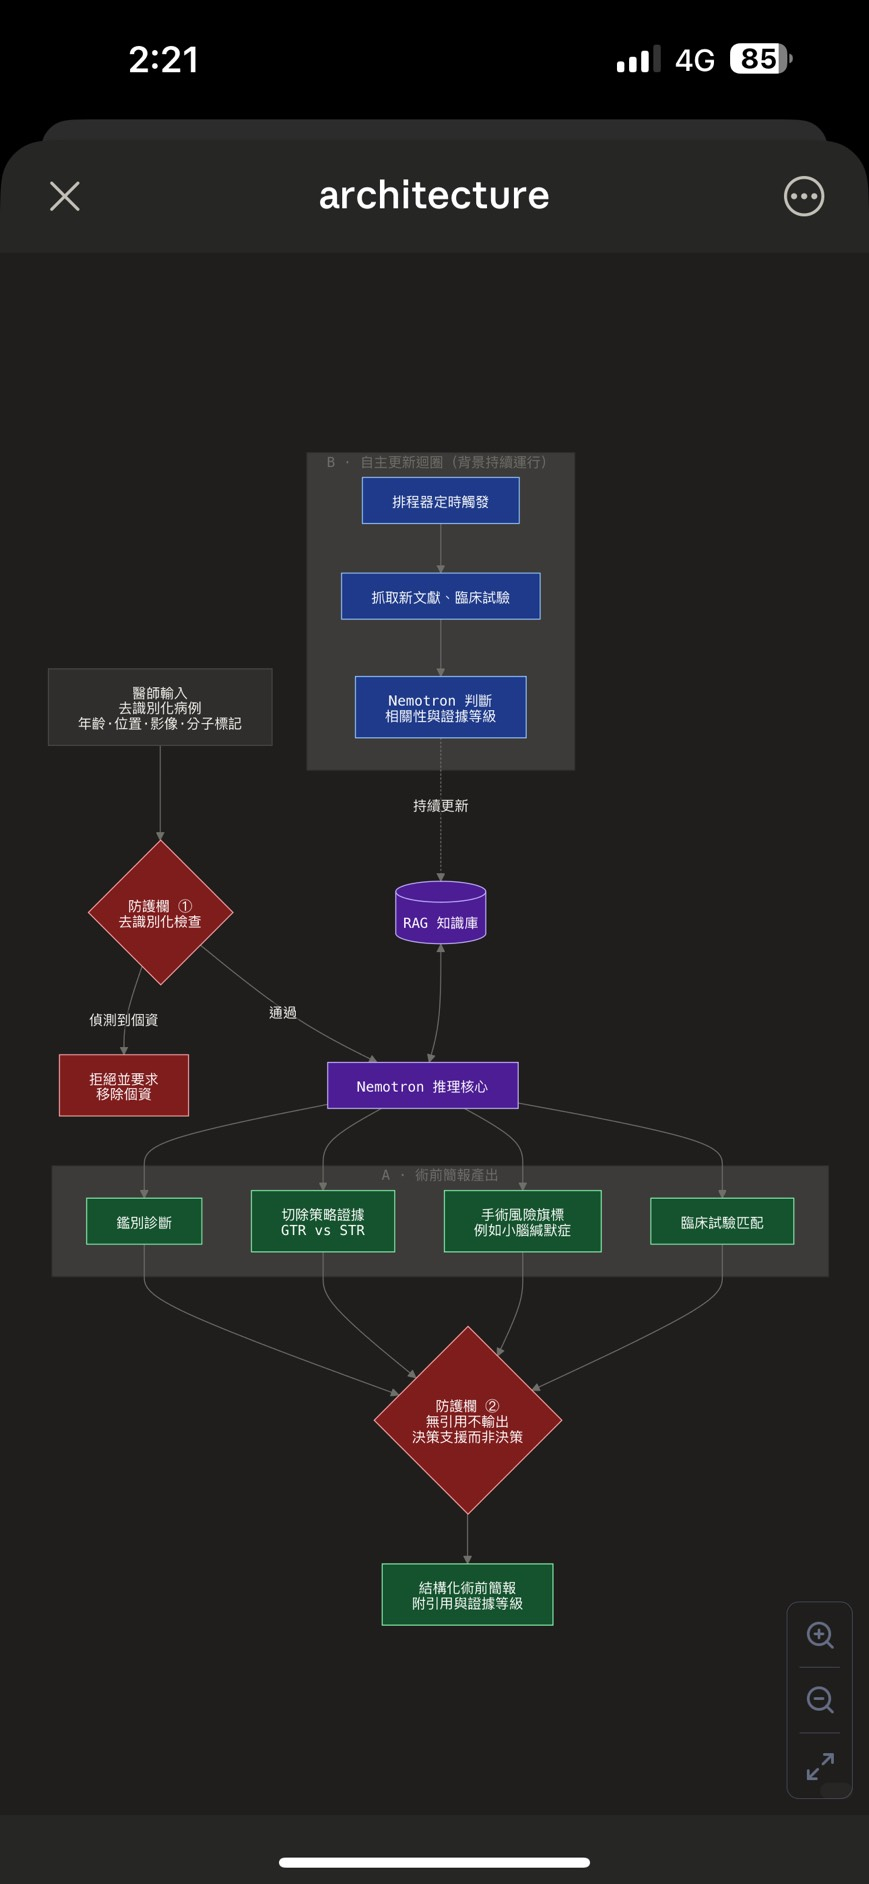

numpy=1.26.4 is compatible.
git clone -q https://github.com/otonifrio2812/pediatric-bt-drug-prediction.git /content/pediatric-bt-drug-prediction
/usr/bin/python3 -m pip install -q -r requirements.txt
wget -q https://github.com/otonifrio2812/pediatric-bt-drug-prediction/releases/download/v1.0.1/intermediates.zip -O /content/pediatric-bt-drug-prediction/intermediates.zip
unzip -q /content/pediatric-bt-drug-prediction/intermediates.zip -d /content/pediatric-bt-drug-prediction/intermediates
✅ drug repo ready: /content/pediatric-bt-drug-prediction


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [17:37:21] WARNING: /workspace/src/collective/../data/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ artifacts loaded
Cancer types: ['Glioblastoma', 'Glioma', 'Neuroblastoma'] ... total = 3
{
  "status": "ok",
  "selected_cancer_type": "Glioma",
  "selected_cell_line_id": "SIDM00085",
  "selected_cell_line_name": "SF268",
  "top_drugs": [
    {
      "drug_name": "Sepantronium bromide",
      "P_sens": 0.597122311592102,
      "CI_lo": 0.597122311592102,
      "CI_hi": 0.597122311592102,
      "target": "BIRC5",
      "pathway": "Apoptosis regulation"
    },
    {
      "drug_name": "Methotrexate",
      "P_sens": 0.4749999940395355,
      "CI_lo": 0.3604806363582611,
      "CI_hi": 0.597122311592102,
      "target": "Antimetabolite",
      "pathway": "DNA replication"
    },
    {
      "drug_name": "Erlotinib",
      "P_sens": 0.4749999940395355,
      "CI_lo": 0.3604806363582611,
      "CI_hi": 0.597122311592102,
      "target": "EGFR",
      "pathway": "EGFR signaling"
    },
    {
      "drug_name": "MG-132",
      "P_sens": 0.4749999940395355,
      "CI_lo": 0.4313725531101227

✅ Enhanced MDT report: outputs/enhanced_mdt_report_with_architecture_and_drugs.md
# Pediatric Neuro-Oncology — Preoperative MDT Support Report
*Generated 2026-05-25 17:35 · Reasoning mode: Nemotron live (nvidia/nemotron-3-super-120b-a12b)*

## 1. De-identified Case Summary
```
7-year-old child.
MRI: diffuse expansile T2-hyperintense lesion infiltrating the pons, encasing the basilar artery, minimal enhancement.
Symptoms: double vision, facial asymmetry, unsteady gait, rapid progression over weeks.
Tumor location: pons (brainstem).
Molecular markers: H3 K27M mutation positive.
Pathology: diffuse midline glioma, H3 K27-altered (WHO grade 4).
Previous treatment: none.
Family's main question: Can surgery remove this tumor?
```
> 🔒 No PHI detected.

## 1b. AI-Assisted Imaging Observations
> 🖼️ Image analysis status: **error** (non-diagnostic; radiologist confirmation required)
- [DWI] 影像辨識失敗；主流程應保留醫師手動輸入的 imaging_description 作為 fallback。
- [FLAIR] 影像辨識失敗；主流程應保留醫師手動輸入的 imaging_description 作為

In [29]:
# ============================================================
# Colab v4 patch: architecture image + drug-ranking system
# Paste after your existing Step 8/9 in pediatric_neuro_oncology_colab_v3.
# ============================================================

# ---------- Step 10A: write adapter modules ----------
# In normal repo use, place these files at project root.
# If running only in Colab, upload/download the two .py files:
#   drug_ranking_adapter.py
#   architecture_report_integration.py

# ---------- Step 10B: add architecture image ----------
import os, glob, shutil
from google.colab import files

os.chdir('/content/pediatric-neuro-oncology-agent')
os.makedirs('assets', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

arch_candidates = (
    glob.glob('腦瘤架構圖.jpg') +
    glob.glob('assets/腦瘤架構圖.jpg') +
    glob.glob('/content/腦瘤架構圖.jpg') +
    glob.glob('/content/*architecture*.jpg') +
    glob.glob('/content/*architecture*.png')
)

if not arch_candidates:
    print('請上傳 腦瘤架構圖.jpg')
    up = files.upload()
    arch_candidates = list(up.keys())

arch_src = arch_candidates[0]
shutil.copyfile(arch_src, 'assets/腦瘤架構圖.jpg')
shutil.copyfile(arch_src, 'outputs/腦瘤架構圖.jpg')
print('✅ architecture image installed:', 'outputs/腦瘤架構圖.jpg')

from architecture_report_integration import display_architecture, install_architecture_asset
display_architecture('outputs/腦瘤架構圖.jpg')


# ---------- Step 10C: setup drug-ranking repo from 06_drug_ranking_widget ----------
# This wraps your 06_drug_ranking_widget.ipynb into reusable code.
import sys, subprocess, json
from drug_ranking_adapter import (
    ensure_numpy_pickle_compatibility,
    setup_drug_ranking_repo,
    load_drug_ranking_artifacts,
    list_available_cancer_types,
    launch_drug_ranking_widget,
    rank_drugs_for_case,
    drug_ranking_to_markdown,
)

compat = ensure_numpy_pickle_compatibility()
print(compat['message'])
if compat.get('needs_restart'):
    raise RuntimeError('請按 Runtime → Restart session，然後從 Step 1 重新執行。')

drug_repo_dir = setup_drug_ranking_repo(
    workdir='/content',
    github_user='otonifrio2812',
    repo_name='pediatric-bt-drug-prediction',
    release_tag='v1.0.1',
)
print('✅ drug repo ready:', drug_repo_dir)

artifacts = load_drug_ranking_artifacts(
    repo_dir=drug_repo_dir,
    intermediates_dir=f'{drug_repo_dir}/intermediates/'
)
cells_by_type = list_available_cancer_types(artifacts, repo_dir=drug_repo_dir)
print('✅ artifacts loaded')
print('Cancer types:', sorted(cells_by_type.keys())[:10], '... total =', len(cells_by_type))


# ---------- Step 10D: run case-level drug ranking ----------
case_for_drug = {
    'age': 7,
    'tumor_type': 'diffuse midline glioma',
    'pathology': 'H3 K27-altered diffuse midline glioma',
    'tumor_location': 'pons',
    'molecular_markers': {'H3K27M': 'positive'},
    # Optional:
    # 'drug_cancer_type': 'Glioma',
    # 'cell_line_id': 'SIDM00083',
}

drug_result = rank_drugs_for_case(
    case_for_drug,
    artifacts=artifacts,
    repo_dir=drug_repo_dir,
    top_k=10,
    with_ci=True,
)

print(json.dumps(drug_result, ensure_ascii=False, indent=2))
print('\n=== Markdown section for MDT report ===')
print(drug_ranking_to_markdown(drug_result))


# ---------- Step 10E: optional interactive widget ----------
# Run this cell line to show the original 06 notebook widget inside this agent notebook.
launch_drug_ranking_widget(artifacts, repo_dir=drug_repo_dir)


# ---------- Step 10F: append architecture + drug section to latest MDT report ----------
from architecture_report_integration import write_enhanced_report

latest_reports = glob.glob('outputs/*.md')
base_report = max(latest_reports, key=os.path.getmtime) if latest_reports else None

enhanced_path = write_enhanced_report(
    output_path='outputs/enhanced_mdt_report_with_architecture_and_drugs.md',
    base_report_path=base_report,
    architecture_image_path='outputs/腦瘤架構圖.jpg',
    drug_result=drug_result,
)

print('✅ Enhanced MDT report:', enhanced_path)
print(open(enhanced_path, encoding='utf-8').read()[:4000])


In [30]:
!pip install -q requests

In [31]:
%%writefile literature_trial_updater.py
# -*- coding: utf-8 -*-
"""
literature_trial_updater.py

Autonomous updater for the Pediatric Neuro-Oncology Surgical Planning Agent.

Purpose:
- Fetch latest PubMed literature.
- Fetch latest ClinicalTrials.gov records.
- Deduplicate.
- Save JSONL files for RAG ingestion.
- Keep audit log.

This module does NOT make clinical recommendations.
It only refreshes evidence sources for downstream Nemotron reasoning + guardrails.
"""

from __future__ import annotations

import os
import json
import time
import hashlib
import datetime as dt
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Dict, List, Any, Optional
from urllib.parse import urlencode

import requests


DEFAULT_QUERY = (
    '("pediatric brain tumor" OR "pediatric neuro-oncology" OR '
    '"diffuse midline glioma" OR "H3 K27-altered" OR "brainstem glioma" OR '
    '"posterior fossa tumor")'
)

PUBMED_ESEARCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
PUBMED_EFETCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
CTGOV_STUDIES = "https://clinicaltrials.gov/api/v2/studies"


def now_iso() -> str:
    return dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z"


def stable_id(prefix: str, text: str) -> str:
    h = hashlib.sha256(text.encode("utf-8", errors="ignore")).hexdigest()[:16]
    return f"{prefix}_{h}"


def load_existing_ids(jsonl_path: str, id_field: str = "id") -> set:
    p = Path(jsonl_path)
    if not p.exists():
        return set()

    ids = set()
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            try:
                obj = json.loads(line)
                if obj.get(id_field):
                    ids.add(obj[id_field])
            except Exception:
                continue
    return ids


def append_jsonl(jsonl_path: str, records: List[Dict[str, Any]], id_field: str = "id") -> int:
    Path(jsonl_path).parent.mkdir(parents=True, exist_ok=True)
    existing = load_existing_ids(jsonl_path, id_field=id_field)

    new_count = 0
    with open(jsonl_path, "a", encoding="utf-8") as f:
        for r in records:
            rid = r.get(id_field)
            if not rid or rid in existing:
                continue
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
            existing.add(rid)
            new_count += 1

    return new_count


def pubmed_search_pmids(
    query: str = DEFAULT_QUERY,
    days: int = 30,
    retmax: int = 50,
) -> List[str]:
    """
    Search recent PubMed records using ESearch.
    """
    params = {
        "db": "pubmed",
        "term": query,
        "reldate": str(days),
        "datetype": "edat",
        "retmax": str(retmax),
        "retmode": "json",
        "sort": "pub_date",
        "tool": os.getenv("NCBI_TOOL", "pediatric_neuro_oncology_agent"),
        "email": os.getenv("NCBI_EMAIL", "your_email@example.com"),
    }

    if os.getenv("NCBI_API_KEY"):
        params["api_key"] = os.getenv("NCBI_API_KEY")

    resp = requests.get(PUBMED_ESEARCH, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    return data.get("esearchresult", {}).get("idlist", [])


def pubmed_fetch_details(pmids: List[str]) -> List[Dict[str, Any]]:
    """
    Fetch PubMed details using EFetch XML.
    """
    if not pmids:
        return []

    params = {
        "db": "pubmed",
        "id": ",".join(pmids),
        "retmode": "xml",
        "tool": os.getenv("NCBI_TOOL", "pediatric_neuro_oncology_agent"),
        "email": os.getenv("NCBI_EMAIL", "your_email@example.com"),
    }

    if os.getenv("NCBI_API_KEY"):
        params["api_key"] = os.getenv("NCBI_API_KEY")

    resp = requests.get(PUBMED_EFETCH, params=params, timeout=60)
    resp.raise_for_status()

    root = ET.fromstring(resp.text)
    records = []

    for article in root.findall(".//PubmedArticle"):
        pmid_el = article.find(".//PMID")
        pmid = pmid_el.text if pmid_el is not None else None

        title_el = article.find(".//ArticleTitle")
        title = "".join(title_el.itertext()).strip() if title_el is not None else ""

        abstract_parts = []
        for abs_el in article.findall(".//AbstractText"):
            label = abs_el.attrib.get("Label")
            text = "".join(abs_el.itertext()).strip()
            if label:
                abstract_parts.append(f"{label}: {text}")
            else:
                abstract_parts.append(text)
        abstract = "\n".join([x for x in abstract_parts if x])

        journal_el = article.find(".//Journal/Title")
        journal = journal_el.text if journal_el is not None else ""

        year_el = article.find(".//PubDate/Year")
        year = year_el.text if year_el is not None else ""

        text_for_hash = f"{pmid}|{title}|{abstract}"
        records.append({
            "id": f"PMID:{pmid}" if pmid else stable_id("pubmed", text_for_hash),
            "source": "PubMed",
            "pmid": pmid,
            "title": title,
            "abstract": abstract,
            "journal": journal,
            "year": year,
            "fetched_at": now_iso(),
            "rag_text": f"Title: {title}\nJournal: {journal} {year}\nAbstract: {abstract}",
        })

    return records


def clinicaltrials_search(
    query: str = "pediatric diffuse midline glioma OR pediatric brain tumor",
    page_size: int = 25,
    max_pages: int = 2,
) -> List[Dict[str, Any]]:
    """
    Fetch ClinicalTrials.gov v2 records.

    Uses public endpoint:
    https://clinicaltrials.gov/api/v2/studies
    """
    records = []
    page_token = None

    for _ in range(max_pages):
        params = {
            "query.term": query,
            "pageSize": str(page_size),
            "format": "json",
        }
        if page_token:
            params["pageToken"] = page_token

        resp = requests.get(CTGOV_STUDIES, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        for study in data.get("studies", []):
            protocol = study.get("protocolSection", {})
            ident = protocol.get("identificationModule", {})
            status = protocol.get("statusModule", {})
            desc = protocol.get("descriptionModule", {})
            cond = protocol.get("conditionsModule", {})
            design = protocol.get("designModule", {})
            arms = protocol.get("armsInterventionsModule", {})

            nct_id = ident.get("nctId")
            title = ident.get("briefTitle") or ident.get("officialTitle") or ""
            summary = desc.get("briefSummary", "")
            conditions = cond.get("conditions", [])
            interventions = arms.get("interventions", [])

            intervention_names = []
            for x in interventions:
                if isinstance(x, dict) and x.get("name"):
                    intervention_names.append(x.get("name"))

            text_for_hash = f"{nct_id}|{title}|{summary}"
            records.append({
                "id": f"NCT:{nct_id}" if nct_id else stable_id("trial", text_for_hash),
                "source": "ClinicalTrials.gov",
                "nct_id": nct_id,
                "title": title,
                "overall_status": status.get("overallStatus"),
                "conditions": conditions,
                "interventions": intervention_names,
                "study_type": design.get("studyType"),
                "summary": summary,
                "fetched_at": now_iso(),
                "rag_text": (
                    f"NCT ID: {nct_id}\n"
                    f"Title: {title}\n"
                    f"Status: {status.get('overallStatus')}\n"
                    f"Conditions: {', '.join(conditions)}\n"
                    f"Interventions: {', '.join(intervention_names)}\n"
                    f"Summary: {summary}"
                ),
            })

        page_token = data.get("nextPageToken")
        if not page_token:
            break

        time.sleep(0.5)

    return records


def refresh_evidence_sources(
    out_dir: str = "rag_sources",
    pubmed_days: int = 30,
    pubmed_retmax: int = 50,
    query: str = DEFAULT_QUERY,
) -> Dict[str, Any]:
    """
    Refresh PubMed + ClinicalTrials sources and write JSONL files.
    """
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    pubmed_path = str(Path(out_dir) / "pubmed_latest.jsonl")
    trials_path = str(Path(out_dir) / "clinicaltrials_latest.jsonl")
    manifest_path = str(Path(out_dir) / "refresh_manifest.json")

    pmids = pubmed_search_pmids(query=query, days=pubmed_days, retmax=pubmed_retmax)
    pubmed_records = pubmed_fetch_details(pmids)

    trial_records = clinicaltrials_search(
        query="pediatric diffuse midline glioma OR pediatric brain tumor",
        page_size=25,
        max_pages=2,
    )

    new_pubmed = append_jsonl(pubmed_path, pubmed_records)
    new_trials = append_jsonl(trials_path, trial_records)

    manifest = {
        "refreshed_at": now_iso(),
        "query": query,
        "pubmed_days": pubmed_days,
        "pubmed_found": len(pubmed_records),
        "pubmed_new": new_pubmed,
        "trials_found": len(trial_records),
        "trials_new": new_trials,
        "pubmed_path": pubmed_path,
        "trials_path": trials_path,
    }

    Path(manifest_path).write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

    Path("logs").mkdir(exist_ok=True)
    with open("logs/autonomous_runs.log", "a", encoding="utf-8") as f:
        f.write(
            f"{now_iso()} EVIDENCE_REFRESH "
            f"pubmed_new={new_pubmed} trials_new={new_trials} "
            f"pubmed_found={len(pubmed_records)} trials_found={len(trial_records)}\n"
        )

    return manifest


if __name__ == "__main__":
    result = refresh_evidence_sources()
    print(json.dumps(result, ensure_ascii=False, indent=2))

Writing literature_trial_updater.py


In [32]:
import os, json

os.chdir("/content/pediatric-neuro-oncology-agent")

# 建議填你自己的 email，符合 NCBI E-utilities usage guideline
os.environ["NCBI_EMAIL"] = "your_email@example.com"
os.environ["NCBI_TOOL"] = "pediatric_neuro_oncology_agent"

from literature_trial_updater import refresh_evidence_sources

manifest = refresh_evidence_sources(
    out_dir="rag_sources",
    pubmed_days=30,
    pubmed_retmax=50,
)

print(json.dumps(manifest, ensure_ascii=False, indent=2))

{
  "refreshed_at": "2026-05-25T17:52:17Z",
  "query": "(\"pediatric brain tumor\" OR \"pediatric neuro-oncology\" OR \"diffuse midline glioma\" OR \"H3 K27-altered\" OR \"brainstem glioma\" OR \"posterior fossa tumor\")",
  "pubmed_days": 30,
  "pubmed_found": 50,
  "pubmed_new": 50,
  "trials_found": 50,
  "trials_new": 50,
  "pubmed_path": "rag_sources/pubmed_latest.jsonl",
  "trials_path": "rag_sources/clinicaltrials_latest.jsonl"
}


In [33]:
%%writefile autonomous_refresh_loop.py
# -*- coding: utf-8 -*-
"""
autonomous_refresh_loop.py

Persistent loop:
1. Refresh PubMed / ClinicalTrials evidence.
2. Run watcher.py --once if available.
3. Sleep for interval hours.
"""

import os
import time
import argparse
import subprocess
import datetime as dt
from pathlib import Path

from literature_trial_updater import refresh_evidence_sources


def ts():
    return dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z"


def run_once(pubmed_days: int = 30, pubmed_retmax: int = 50):
    print(f"[{ts()}] Refreshing evidence sources...")
    manifest = refresh_evidence_sources(
        out_dir="rag_sources",
        pubmed_days=pubmed_days,
        pubmed_retmax=pubmed_retmax,
    )
    print(manifest)

    # If your existing watcher.py exists, call it.
    # This preserves your current RAG / autonomous run design.
    if Path("watcher.py").exists():
        print(f"[{ts()}] Running watcher.py --once ...")
        subprocess.run(["python", "watcher.py", "--once"], check=False)
    else:
        print(f"[{ts()}] watcher.py not found; evidence refresh only.")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--interval-hours", type=float, default=6.0)
    parser.add_argument("--once", action="store_true")
    parser.add_argument("--pubmed-days", type=int, default=30)
    parser.add_argument("--pubmed-retmax", type=int, default=50)
    args = parser.parse_args()

    Path("logs").mkdir(exist_ok=True)

    if args.once:
        run_once(pubmed_days=args.pubmed_days, pubmed_retmax=args.pubmed_retmax)
        return

    while True:
        try:
            run_once(pubmed_days=args.pubmed_days, pubmed_retmax=args.pubmed_retmax)
        except Exception as exc:
            print(f"[{ts()}] ERROR: {exc}")

        sleep_sec = int(args.interval_hours * 3600)
        print(f"[{ts()}] Sleeping {args.interval_hours} hours...")
        time.sleep(sleep_sec)


if __name__ == "__main__":
    main()

Writing autonomous_refresh_loop.py


In [34]:
!python autonomous_refresh_loop.py --once --pubmed-days 30 --pubmed-retmax 30
!tail -n 20 logs/autonomous_runs.log

/content/pediatric-neuro-oncology-agent/autonomous_refresh_loop.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z"
[2026-05-25T17:52:46Z] Refreshing evidence sources...
{'refreshed_at': '2026-05-25T17:52:48Z', 'query': '("pediatric brain tumor" OR "pediatric neuro-oncology" OR "diffuse midline glioma" OR "H3 K27-altered" OR "brainstem glioma" OR "posterior fossa tumor")', 'pubmed_days': 30, 'pubmed_found': 30, 'pubmed_new': 0, 'trials_found': 50, 'trials_new': 0, 'pubmed_path': 'rag_sources/pubmed_latest.jsonl', 'trials_path': 'rag_sources/clinicaltrials_latest.jsonl'}
[2026-05-25T17:52:48Z] Running watcher.py --once ...
[2026-05-25T17:52:49.883850] autonomous refresh: +0 new, 8 chunks indexed
2026-05-25T15:22:40.819244 CASE_RUN mode=Nemotron live (nvidia/nemo

In [39]:
!nohup python autonomous_refresh_loop.py \
  --interval-hours 6 \
  --pubmed-days 30 \
  --pubmed-retmax 50 \
  > logs/refresh_loop_stdout.log 2>&1 &

In [40]:
rag_sources/pubmed_latest.jsonl
rag_sources/clinicaltrials_latest.jsonl
rag_sources/refresh_manifest.json

NameError: name 'rag_sources' is not defined

In [41]:
import json
from pathlib import Path

def load_external_rag_sources(source_dir="rag_sources"):
    docs = []
    for path in Path(source_dir).glob("*.jsonl"):
        with open(path, encoding="utf-8") as f:
            for line in f:
                try:
                    obj = json.loads(line)
                    docs.append({
                        "id": obj.get("id"),
                        "source": obj.get("source"),
                        "text": obj.get("rag_text") or obj.get("abstract") or obj.get("summary") or "",
                        "metadata": obj,
                    })
                except Exception:
                    continue
    return docs

In [42]:
from pathlib import Path
import json

Path("knowledge_base").mkdir(exist_ok=True)

texts = []
for p in Path("rag_sources").glob("*.jsonl"):
    with open(p, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            texts.append(
                f"### {obj.get('id')} | {obj.get('source')}\n"
                f"{obj.get('rag_text', '')}\n"
            )

Path("knowledge_base/external_updates.md").write_text(
    "\n\n".join(texts),
    encoding="utf-8"
)

print("Wrote knowledge_base/external_updates.md")

Wrote knowledge_base/external_updates.md



## Step 11 — Advanced DICOM/NIfTI imaging module

這一段會新增 `advanced_medical_imaging.py`，支援 DICOM / NIfTI 讀取、序列判斷、示範用腫瘤 segmentation、結構化影像欄位、病例文字 cross-check，以及 `outputs/surgical_risk_map.jpg`。

⚠️ Safety: segmentation/location/risk map 是 hackathon research prototype，不能作為確定診斷或手術決策。正式版要替換成 validated MONAI / nnUNet / atlas-registration pipeline。


In [ ]:
!pip install -q pydicom nibabel scipy matplotlib
print("✅ Advanced imaging dependencies installed")


In [ ]:
%%writefile advanced_medical_imaging.py
# -*- coding: utf-8 -*-
"""
advanced_medical_imaging.py

Advanced medical imaging helper for the Pediatric Neuro-Oncology Surgical
Planning Agent. Designed for Colab and hackathon demo workflows.

What it does:
- Reads DICOM folders / DICOM files / NIfTI (.nii, .nii.gz) volumes.
- Auto-detects MRI sequences: T1, T1C, T2, FLAIR, DWI, ADC, SWI/GRE.
- Produces a DEMO tumor mask using a heuristic fallback segmenter.
- Classifies rough tumor location: pons, midbrain, medulla, thalamus,
  spinal_cord, other, indeterminate.
- Extracts structured fields: enhancement, necrosis, hemorrhage,
  diffusion restriction, hydrocephalus.
- Cross-checks imaging findings against case text.
- Produces a neurosurgery-facing surgical risk map JPG.

Safety scope:
- This module is a research prototype / hackathon component.
- It must NOT be used for definitive diagnosis, treatment, or operative planning.
- The segmentation and anatomy landmarks are heuristic placeholders.
- Formal use should replace segment_tumor() and landmark logic with validated
  MONAI / nnUNet / atlas-registration components.
- DICOM must be de-identified before cloud upload or external processing.

中文重點：
- 可跑 DICOM / NIfTI，但 segmentation 是示範用 heuristic，不是正式醫療模型。
- 只產生「輔助觀察」和結構化欄位，不輸出確定診斷。
"""

from __future__ import annotations

import json
import math
import os
import re
import shutil
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple, Union

import numpy as np

try:
    import nibabel as nib
except Exception:  # pragma: no cover
    nib = None

try:
    import pydicom
except Exception:  # pragma: no cover
    pydicom = None

try:
    from scipy import ndimage as ndi
except Exception:  # pragma: no cover
    ndi = None

try:
    import matplotlib.pyplot as plt
except Exception:  # pragma: no cover
    plt = None


DISCLAIMER = (
    "AI 影像輔助分析（research prototype），不可作為確定性診斷、治療或手術決策依據；"
    "最終判讀與手術決策須由放射科／神經外科／兒童神經腫瘤 MDT 負責。"
)

PRIVACY_NOTE = (
    "DICOM / NIfTI 影像在上傳雲端或外部服務前必須先去識別化；"
    "需移除 DICOM metadata 中的姓名、病歷號、生日、檢查日期等 PHI，"
    "並檢查影像邊框是否有 burned-in 文字。"
)

SEQUENCE_ORDER = ["T1C", "FLAIR", "T2", "DWI", "T1", "ADC", "SWI/GRE", "CT", "PET", "UNKNOWN"]
LOCATION_CLASSES = ["pons", "midbrain", "medulla", "thalamus", "spinal_cord", "other", "indeterminate"]


# -----------------------------------------------------------------------------
# Utilities
# -----------------------------------------------------------------------------

def _safe_str(x: Any) -> str:
    if x is None:
        return ""
    try:
        return str(x)
    except Exception:
        return ""


def _lower(x: Any) -> str:
    return _safe_str(x).lower()


def _json_safe(obj: Any) -> Any:
    """Convert NumPy / Path / tuple objects to JSON-safe values."""
    if isinstance(obj, dict):
        return {str(k): _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def _ensure_dir(path: Union[str, Path]) -> str:
    Path(path).mkdir(parents=True, exist_ok=True)
    return str(path)


def _percentile_normalize(arr: np.ndarray, p_low: float = 1, p_high: float = 99) -> np.ndarray:
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    if arr.size == 0:
        return arr
    lo, hi = np.percentile(arr, [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo + 1e-6:
        return np.zeros_like(arr, dtype=np.float32)
    arr = np.clip(arr, lo, hi)
    return ((arr - lo) / (hi - lo)).astype(np.float32)


def _maybe_open_zip(input_path: Union[str, Path], work_dir: str = "medical_inputs_unzipped") -> Union[str, Path]:
    p = Path(input_path)
    if p.is_file() and p.suffix.lower() == ".zip":
        out = Path(work_dir)
        out.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(str(p), "r") as zf:
            zf.extractall(str(out))
        return out
    return input_path


def _collect_input_files(path_or_paths: Union[str, Path, Sequence[Union[str, Path]]]) -> List[str]:
    if isinstance(path_or_paths, (list, tuple, set)):
        files: List[str] = []
        for x in path_or_paths:
            files.extend(_collect_input_files(x))
        return sorted(set(files))

    p = Path(path_or_paths)
    p = Path(_maybe_open_zip(p))
    if p.is_file():
        return [str(p)]
    if p.is_dir():
        files = []
        for root, _, names in os.walk(str(p)):
            for name in names:
                if name.startswith("."):
                    continue
                files.append(str(Path(root) / name))
        return sorted(files)
    return []


def _is_nifti(path: Union[str, Path]) -> bool:
    s = str(path).lower()
    return s.endswith(".nii") or s.endswith(".nii.gz")


def _dicom_available() -> bool:
    return pydicom is not None


def _is_dicom(path: Union[str, Path]) -> bool:
    if pydicom is None:
        return False
    s = str(path).lower()
    if s.endswith(".dcm") or s.endswith(".dicom"):
        return True
    try:
        pydicom.dcmread(str(path), stop_before_pixels=True, force=True)
        return True
    except Exception:
        return False


def _status(status: str, evidence: str, confidence: str = "low") -> Dict[str, str]:
    return {"status": status, "evidence": evidence, "confidence": confidence}


# -----------------------------------------------------------------------------
# Sequence detection
# -----------------------------------------------------------------------------

def infer_sequence_label(text: str) -> str:
    """Infer sequence label from DICOM tags or filename."""
    s = _lower(text).replace("_", " ").replace("-", " ")

    # Post-contrast T1 / T1C must be checked before plain T1.
    if any(k in s for k in [
        "t1c", "t1 c", "t1+c", "t1 + c", "t1 post", "post t1", "postcontrast",
        "post contrast", "post gad", "gadolinium", "gd", "t1ce", "t1 ce", "ce t1",
        "mprage post", "bravo post", "spgr post",
    ]):
        return "T1C"
    if "adc" in s or "apparent diffusion" in s:
        return "ADC"
    if any(k in s for k in ["dwi", "diffusion", "trace", "b1000", "b 1000", "b800", "b 800"]):
        return "DWI"
    if "flair" in s:
        return "FLAIR"
    if any(k in s for k in ["swi", "susceptibility", "gre", "t2*", "t2 star", "t2star", "hemosiderin"]):
        return "SWI/GRE"
    if re.search(r"\bt2\b", s) or "tse t2" in s or "frfse" in s:
        return "T2"
    if re.search(r"\bt1\b", s) or "mprage" in s or "bravo" in s or "spgr" in s:
        return "T1"
    if re.search(r"\bct\b", s) or "computed tomography" in s:
        return "CT"
    if re.search(r"\bpet\b", s):
        return "PET"
    return "UNKNOWN"


def _unique_sequence_key(existing: Dict[str, Any], seq: str) -> str:
    if seq not in existing:
        return seq
    i = 2
    while f"{seq}_{i}" in existing:
        i += 1
    return f"{seq}_{i}"


def canonical_sequence(seq_key: str) -> str:
    """Return canonical base sequence without _2 suffix."""
    return re.sub(r"_\d+$", "", seq_key)


# -----------------------------------------------------------------------------
# Study loaders
# -----------------------------------------------------------------------------

@dataclass
class SeriesVolume:
    key: str
    sequence: str
    volume: np.ndarray
    source_type: str
    path: str
    spacing: Tuple[float, float, float]
    affine: np.ndarray
    metadata: Dict[str, Any]

    def as_public_dict(self) -> Dict[str, Any]:
        return {
            "key": self.key,
            "sequence": self.sequence,
            "source_type": self.source_type,
            "path": self.path,
            "shape": list(self.volume.shape),
            "spacing": list(self.spacing),
            "metadata": self.metadata,
        }


def _read_nifti(path: str) -> Optional[SeriesVolume]:
    if nib is None:
        raise ImportError("nibabel is required for NIfTI support. Please install nibabel.")
    img = nib.load(path)
    data = img.get_fdata(dtype=np.float32)
    if data.ndim == 4:
        # Demo: use first volume in 4D file. Formal pipeline should handle multi-volume DWI correctly.
        data = data[..., 0]
    # Nibabel returns X,Y,Z; transpose to Z,Y,X for consistent display.
    if data.ndim != 3:
        raise ValueError(f"NIfTI volume must be 3D or 4D, got shape {data.shape}: {path}")
    vol = np.transpose(data, (2, 1, 0)).astype(np.float32)
    zooms = img.header.get_zooms()[:3]
    spacing_xyz = tuple(float(x) for x in zooms) if len(zooms) >= 3 else (1.0, 1.0, 1.0)
    spacing_zyx = (spacing_xyz[2], spacing_xyz[1], spacing_xyz[0])
    seq = infer_sequence_label(Path(path).name)
    return SeriesVolume(
        key=seq,
        sequence=seq,
        volume=vol,
        source_type="NIFTI",
        path=str(path),
        spacing=spacing_zyx,
        affine=np.asarray(img.affine, dtype=np.float32),
        metadata={"filename": Path(path).name},
    )


def _dicom_sort_key(ds: Any) -> float:
    ipp = getattr(ds, "ImagePositionPatient", None)
    if ipp is not None and len(ipp) >= 3:
        try:
            return float(ipp[2])
        except Exception:
            pass
    inst = getattr(ds, "InstanceNumber", None)
    try:
        return float(inst)
    except Exception:
        return 0.0


def _get_dicom_spacing(first: Any) -> Tuple[float, float, float]:
    px = getattr(first, "PixelSpacing", [1.0, 1.0])
    try:
        row = float(px[0])
        col = float(px[1])
    except Exception:
        row, col = 1.0, 1.0
    try:
        z = float(getattr(first, "SpacingBetweenSlices", getattr(first, "SliceThickness", 1.0)))
    except Exception:
        z = 1.0
    return (z, row, col)


def _read_dicom_series(dicom_files: List[str]) -> Dict[str, SeriesVolume]:
    if pydicom is None:
        raise ImportError("pydicom is required for DICOM support. Please install pydicom.")

    grouped: Dict[str, List[Any]] = {}
    source_paths: Dict[str, List[str]] = {}

    for fp in dicom_files:
        try:
            ds = pydicom.dcmread(fp, force=True)
            if not hasattr(ds, "PixelData"):
                continue
            uid = _safe_str(getattr(ds, "SeriesInstanceUID", "")) or _safe_str(getattr(ds, "SeriesNumber", "")) or f"series_{len(grouped)+1}"
            grouped.setdefault(uid, []).append(ds)
            source_paths.setdefault(uid, []).append(fp)
        except Exception:
            continue

    series: Dict[str, SeriesVolume] = {}
    for uid, dss in grouped.items():
        if not dss:
            continue
        dss = sorted(dss, key=_dicom_sort_key)
        first = dss[0]
        desc_parts = [
            getattr(first, "SeriesDescription", ""),
            getattr(first, "ProtocolName", ""),
            getattr(first, "SequenceName", ""),
            getattr(first, "ScanningSequence", ""),
            getattr(first, "MRAcquisitionType", ""),
            Path(source_paths.get(uid, [""])[0]).name,
        ]
        seq = infer_sequence_label(" ".join(_safe_str(x) for x in desc_parts))
        key = _unique_sequence_key(series, seq)

        slices: List[np.ndarray] = []
        for ds in dss:
            try:
                arr = ds.pixel_array.astype(np.float32)
                slope = float(getattr(ds, "RescaleSlope", 1.0))
                intercept = float(getattr(ds, "RescaleIntercept", 0.0))
                arr = arr * slope + intercept
                if arr.ndim == 2:
                    slices.append(arr)
                elif arr.ndim == 3:
                    # multi-frame DICOM fallback
                    for i in range(arr.shape[0]):
                        slices.append(arr[i])
            except Exception as exc:
                warnings.warn(f"Could not read pixel array for one DICOM slice: {exc}")

        if not slices:
            continue
        if len(slices) == 1:
            vol = slices[0][None, :, :]
        else:
            try:
                vol = np.stack(slices, axis=0)
            except Exception:
                # fallback: keep only compatible slices
                shapes = {}
                for sl in slices:
                    shapes[sl.shape] = shapes.get(sl.shape, 0) + 1
                keep_shape = sorted(shapes.items(), key=lambda kv: kv[1], reverse=True)[0][0]
                vol = np.stack([sl for sl in slices if sl.shape == keep_shape], axis=0)

        metadata = {
            "SeriesDescription": _safe_str(getattr(first, "SeriesDescription", "")),
            "ProtocolName": _safe_str(getattr(first, "ProtocolName", "")),
            "SequenceName": _safe_str(getattr(first, "SequenceName", "")),
            "Modality": _safe_str(getattr(first, "Modality", "")),
            "SeriesInstanceUID": uid,
            "n_slices": int(vol.shape[0]),
        }
        series[key] = SeriesVolume(
            key=key,
            sequence=canonical_sequence(key),
            volume=vol.astype(np.float32),
            source_type="DICOM",
            path=f"DICOM_SERIES:{uid}",
            spacing=_get_dicom_spacing(first),
            affine=np.eye(4, dtype=np.float32),
            metadata=metadata,
        )

    return series


def load_study(path_or_paths: Union[str, Path, Sequence[Union[str, Path]]]) -> Dict[str, SeriesVolume]:
    """Load DICOM and/or NIfTI study into sequence-keyed volumes."""
    files = _collect_input_files(path_or_paths)
    if not files:
        raise FileNotFoundError(f"No input files found: {path_or_paths}")

    series: Dict[str, SeriesVolume] = {}

    for fp in files:
        if _is_nifti(fp):
            sv = _read_nifti(fp)
            if sv is not None:
                key = _unique_sequence_key(series, sv.sequence)
                sv.key = key
                series[key] = sv

    dicom_files = [fp for fp in files if _is_dicom(fp)]
    if dicom_files:
        series.update(_read_dicom_series(dicom_files))

    if not series:
        raise ValueError("No readable DICOM or NIfTI series found. Please upload .nii/.nii.gz or DICOM folder/zip.")

    return series


# -----------------------------------------------------------------------------
# Segmentation and measurement helpers
# -----------------------------------------------------------------------------

def _binary_ops_available() -> bool:
    return ndi is not None


def _simple_brain_mask(vol: np.ndarray) -> np.ndarray:
    v = _percentile_normalize(vol)
    if ndi is None:
        return v > max(0.05, float(np.percentile(v, 20)))
    mask = v > max(0.05, float(np.percentile(v, 20)))
    try:
        mask = ndi.binary_fill_holes(mask)
        mask = ndi.binary_opening(mask, structure=np.ones((3, 3, 3)))
        mask = ndi.binary_closing(mask, structure=np.ones((3, 3, 3)))
        labels, n = ndi.label(mask)
        if n > 0:
            sizes = ndi.sum(mask, labels, index=np.arange(1, n + 1))
            largest = int(np.argmax(sizes)) + 1
            mask = labels == largest
    except Exception:
        pass
    return mask.astype(bool)


def _choose_sequence(series: Dict[str, SeriesVolume], preference: Sequence[str] = ("T1C", "FLAIR", "T2", "DWI", "T1", "ADC", "SWI/GRE")) -> Tuple[str, SeriesVolume]:
    for pref in preference:
        for key, sv in series.items():
            if canonical_sequence(key) == pref:
                return key, sv
    key = list(series.keys())[0]
    return key, series[key]


def _largest_reasonable_component(mask: np.ndarray) -> np.ndarray:
    if mask.sum() == 0 or ndi is None:
        return mask.astype(bool)
    labels, n = ndi.label(mask)
    if n == 0:
        return np.zeros_like(mask, dtype=bool)
    sizes = ndi.sum(mask, labels, index=np.arange(1, n + 1))
    shape = np.asarray(mask.shape, dtype=np.float32)
    center = (shape - 1) / 2.0
    best_label = None
    best_score = -1e18
    for idx, size in enumerate(sizes, start=1):
        if size < 20:
            continue
        comp = labels == idx
        try:
            com = np.asarray(ndi.center_of_mass(comp), dtype=np.float32)
        except Exception:
            com = center
        dist = float(np.linalg.norm((com - center) / np.maximum(shape, 1)))
        # bias toward larger and central components; useful only for demo fallback.
        score = float(size) - 500.0 * dist
        if score > best_score:
            best_score = score
            best_label = idx
    if best_label is None:
        return np.zeros_like(mask, dtype=bool)
    return (labels == best_label)


def segment_tumor(series: Dict[str, SeriesVolume]) -> Dict[str, Any]:
    """
    DEMO heuristic tumor segmentation.

    Formal replacement target:
    - MONAI / nnUNet / BraTS-like model trained or validated for pediatric tumors.
    - Atlas registration / sequence-aware fusion.
    """
    seq_key, sv = _choose_sequence(series)
    vol = sv.volume
    v = _percentile_normalize(vol)
    brain = _simple_brain_mask(vol)

    vals = v[brain]
    if vals.size < 50:
        mask = np.zeros_like(v, dtype=bool)
    else:
        mu = float(vals.mean())
        sd = float(vals.std()) + 1e-6
        base_seq = canonical_sequence(seq_key)
        if base_seq in {"FLAIR", "T2", "T1C", "DWI"}:
            threshold = max(mu + 1.15 * sd, float(np.percentile(vals, 88)))
        else:
            threshold = max(mu + 1.45 * sd, float(np.percentile(vals, 92)))
        mask = (v > threshold) & brain
        if ndi is not None:
            try:
                mask = ndi.binary_opening(mask, structure=np.ones((2, 2, 2)))
                mask = ndi.binary_closing(mask, structure=np.ones((3, 3, 3)))
                mask = ndi.binary_fill_holes(mask)
            except Exception:
                pass
        mask = _largest_reasonable_component(mask)

    spacing = np.asarray(sv.spacing, dtype=np.float32)
    voxel_volume_mm3 = float(np.prod(spacing)) if spacing.size == 3 else 1.0
    volume_voxels = int(mask.sum())
    volume_ml = float(volume_voxels * voxel_volume_mm3 / 1000.0)

    return {
        "mask": mask.astype(bool),
        "source_sequence_key": seq_key,
        "source_sequence": canonical_sequence(seq_key),
        "method": "heuristic_fallback_demo_not_validated",
        "confidence": "low",
        "volume_voxels": volume_voxels,
        "volume_ml_rough": round(volume_ml, 3),
        "voxel_spacing_zyx_mm": [float(x) for x in spacing.tolist()],
    }


def _centroid(mask: np.ndarray) -> Optional[np.ndarray]:
    if mask.sum() == 0:
        return None
    if ndi is not None:
        try:
            return np.asarray(ndi.center_of_mass(mask), dtype=np.float32)
        except Exception:
            pass
    coords = np.argwhere(mask)
    if coords.size == 0:
        return None
    return coords.mean(axis=0).astype(np.float32)


def _normalized_centroid(mask: np.ndarray) -> Optional[np.ndarray]:
    c = _centroid(mask)
    if c is None:
        return None
    shape = np.asarray(mask.shape, dtype=np.float32)
    return c / np.maximum(shape - 1, 1)


def classify_location(mask: np.ndarray) -> Dict[str, Any]:
    """
    Rough location classifier based on normalized centroid.

    This is a placeholder. Production should use atlas registration or a validated classifier.
    """
    c = _normalized_centroid(mask)
    if c is None:
        return {"primary": "indeterminate", "confidence": "low", "centroid_normalized_zyx": None}

    z, y, x = [float(v) for v in c]
    # Heuristic for demo: posterior fossa / midline structure bands.
    if z < 0.24:
        loc = "thalamus"
    elif z < 0.38:
        loc = "midbrain"
    elif z < 0.55:
        loc = "pons"
    elif z < 0.72:
        loc = "medulla"
    else:
        loc = "spinal_cord"

    # If very lateral, reduce confidence and mark other.
    if abs(x - 0.5) > 0.30:
        loc = "other"

    return {
        "primary": loc,
        "confidence": "low",
        "centroid_normalized_zyx": [round(z, 3), round(y, 3), round(x, 3)],
        "note": "Heuristic location only; formal use requires atlas registration or expert review.",
    }


# -----------------------------------------------------------------------------
# Structured findings
# -----------------------------------------------------------------------------

def _find_sequence(series: Dict[str, SeriesVolume], seq: str) -> Optional[SeriesVolume]:
    for key, sv in series.items():
        if canonical_sequence(key) == seq:
            return sv
    return None


def _same_shape(a: np.ndarray, b: np.ndarray) -> bool:
    return tuple(a.shape) == tuple(b.shape)


def _masked_mean(vol: np.ndarray, mask: np.ndarray) -> Optional[float]:
    if mask.sum() == 0 or not _same_shape(vol, mask):
        return None
    vals = vol[mask]
    if vals.size == 0:
        return None
    return float(np.mean(vals))


def assess_enhancement(series: Dict[str, SeriesVolume], mask: np.ndarray) -> Dict[str, str]:
    t1 = _find_sequence(series, "T1")
    t1c = _find_sequence(series, "T1C")
    if t1 is None or t1c is None:
        return _status("indeterminate", "Needs paired T1 and T1C sequences.")
    if not _same_shape(t1.volume, t1c.volume) or not _same_shape(t1.volume, mask):
        return _status("indeterminate", "T1/T1C/mask shapes differ; registration not implemented in demo.")
    t1v = _percentile_normalize(t1.volume)
    t1cv = _percentile_normalize(t1c.volume)
    m1 = _masked_mean(t1v, mask)
    m2 = _masked_mean(t1cv, mask)
    if m1 is None or m2 is None:
        return _status("indeterminate", "No tumor mask statistics available.")
    diff = m2 - m1
    if diff > 0.12:
        return _status("possible_present", f"T1C mean exceeds T1 by {diff:.3f} in heuristic mask.")
    if diff > 0.05:
        return _status("mild_or_equivocal", f"T1C-T1 difference {diff:.3f}.")
    return _status("not_prominent", f"T1C-T1 difference {diff:.3f}.")


def assess_necrosis(series: Dict[str, SeriesVolume], mask: np.ndarray) -> Dict[str, str]:
    sv = _find_sequence(series, "T1C") or _find_sequence(series, "FLAIR") or _find_sequence(series, "T2")
    if sv is None:
        return _status("indeterminate", "Needs T1C, FLAIR, or T2 sequence.")
    if mask.sum() == 0 or not _same_shape(sv.volume, mask):
        return _status("indeterminate", "Tumor mask unavailable or unregistered.")
    v = _percentile_normalize(sv.volume)
    vals = v[mask]
    if vals.size < 20:
        return _status("indeterminate", "Tumor mask too small for necrosis surrogate.")
    low_frac = float((vals < np.percentile(vals, 20)).mean())
    if low_frac > 0.30:
        return _status("possible", f"Internal low-signal fraction {low_frac:.2f} in {sv.sequence} mask.")
    return _status("not_prominent", f"Internal low-signal fraction {low_frac:.2f}.")


def assess_hemorrhage(series: Dict[str, SeriesVolume], mask: np.ndarray) -> Dict[str, str]:
    swi = _find_sequence(series, "SWI/GRE")
    if swi is None:
        return _status("indeterminate", "Needs SWI/GRE or CT for hemorrhage surrogate.")
    if mask.sum() == 0 or not _same_shape(swi.volume, mask):
        return _status("indeterminate", "Tumor mask unavailable or unregistered.")
    v = _percentile_normalize(swi.volume)
    vals = v[mask]
    if vals.size < 20:
        return _status("indeterminate", "Tumor mask too small.")
    low_global = float(np.percentile(v, 10))
    low_frac = float((vals < low_global).mean())
    if low_frac > 0.15:
        return _status("possible", f"Low-signal foci fraction {low_frac:.2f} on SWI/GRE surrogate.")
    return _status("not_obvious", f"Low-signal foci fraction {low_frac:.2f}.")


def assess_diffusion_restriction(series: Dict[str, SeriesVolume], mask: np.ndarray) -> Dict[str, str]:
    dwi = _find_sequence(series, "DWI")
    adc = _find_sequence(series, "ADC")
    if dwi is None or adc is None:
        return _status("indeterminate", "Needs both DWI and ADC.")
    if not _same_shape(dwi.volume, adc.volume) or not _same_shape(dwi.volume, mask):
        return _status("indeterminate", "DWI/ADC/mask shapes differ; registration not implemented in demo.")
    dwi_v = _percentile_normalize(dwi.volume)
    adc_v = _percentile_normalize(adc.volume)
    dwi_mean = _masked_mean(dwi_v, mask)
    adc_mean = _masked_mean(adc_v, mask)
    if dwi_mean is None or adc_mean is None:
        return _status("indeterminate", "No tumor mask statistics available.")
    if dwi_mean > 0.60 and adc_mean < 0.45:
        return _status("possible_present", f"DWI mean {dwi_mean:.2f}, ADC mean {adc_mean:.2f}.")
    return _status("not_prominent", f"DWI mean {dwi_mean:.2f}, ADC mean {adc_mean:.2f}.")


def assess_hydrocephalus(series: Dict[str, SeriesVolume], mask: np.ndarray, location: Dict[str, Any]) -> Dict[str, str]:
    c = _normalized_centroid(mask)
    if c is None:
        return _status("indeterminate", "No tumor centroid.")
    loc = location.get("primary", "indeterminate")
    # Approximate fourth ventricle region in normalized ZYX coordinate for demo.
    fourth_ventricle = np.array([0.54, 0.52, 0.50], dtype=np.float32)
    dist = float(np.linalg.norm(c - fourth_ventricle))
    if loc in {"pons", "midbrain", "medulla"} and dist < 0.18:
        return _status("possible", f"Brainstem/posterior-fossa mass near fourth-ventricle surrogate ROI; distance={dist:.2f}.")
    return _status("not_obvious", f"No strong fourth-ventricle obstruction surrogate; distance={dist:.2f}.")


def extract_structured_findings(series: Dict[str, SeriesVolume], segmentation: Dict[str, Any], location: Dict[str, Any]) -> Dict[str, Any]:
    mask = segmentation["mask"]
    return {
        "tumor_detected": bool(mask.sum() > 0),
        "tumor_volume_voxels": int(segmentation.get("volume_voxels", 0)),
        "tumor_volume_ml_rough": float(segmentation.get("volume_ml_rough", 0.0)),
        "source_sequence_for_segmentation": segmentation.get("source_sequence"),
        "segmentation_method": segmentation.get("method"),
        "segmentation_confidence": segmentation.get("confidence"),
        "location": location,
        "enhancement": assess_enhancement(series, mask),
        "necrosis": assess_necrosis(series, mask),
        "hemorrhage": assess_hemorrhage(series, mask),
        "diffusion_restriction": assess_diffusion_restriction(series, mask),
        "hydrocephalus": assess_hydrocephalus(series, mask, location),
    }


# -----------------------------------------------------------------------------
# Cross-check with case text
# -----------------------------------------------------------------------------

def _case_text(structured_case: Optional[Dict[str, Any]]) -> str:
    if not structured_case:
        return ""
    chunks = []
    for key in [
        "age", "tumor_type", "tumor_location", "pathology", "symptoms",
        "imaging_description", "molecular_markers", "raw_case_text",
    ]:
        value = structured_case.get(key)
        if value is None:
            continue
        if isinstance(value, (dict, list, tuple)):
            chunks.append(json.dumps(value, ensure_ascii=False))
        else:
            chunks.append(str(value))
    return "\n".join(chunks).lower()


def cross_check_case(structured_case: Optional[Dict[str, Any]], findings: Dict[str, Any]) -> Dict[str, List[str]]:
    text = _case_text(structured_case)
    concordant: List[str] = []
    discrepant: List[str] = []
    notes: List[str] = []

    loc = findings.get("location", {}).get("primary", "indeterminate")
    if loc != "indeterminate":
        if loc in text:
            concordant.append(f"Case text explicitly mentions imaging-compatible location: {loc}.")
        elif structured_case and structured_case.get("tumor_location"):
            discrepant.append(
                f"Case tumor_location='{structured_case.get('tumor_location')}' does not explicitly match imaging-derived location='{loc}'."
            )
        else:
            notes.append(f"Imaging-derived location surrogate is '{loc}', not stated in case text.")

    field_terms = {
        "hydrocephalus": ["hydrocephalus", "ventriculomegaly", "ventricular enlargement"],
        "hemorrhage": ["hemorrhage", "haemorrhage", "bleed", "swi", "gre"],
        "diffusion_restriction": ["diffusion restriction", "restricted diffusion", "adc", "dwi"],
        "enhancement": ["enhancement", "enhancing", "contrast"],
        "necrosis": ["necrosis", "necrotic"],
    }
    for field, terms in field_terms.items():
        status = findings.get(field, {}).get("status", "")
        if status in {"possible", "possible_present", "present"} and not any(t in text for t in terms):
            notes.append(f"Imaging module flags {field} as {status}, but the case text does not clearly mention it.")

    pathology = ""
    if structured_case:
        pathology = _lower(structured_case.get("pathology", "")) + " " + _lower(structured_case.get("tumor_type", ""))
    if "diffuse midline" in pathology or "h3 k27" in pathology or "h3k27" in pathology:
        if loc in {"pons", "midbrain", "medulla", "thalamus", "spinal_cord"}:
            concordant.append("Pathology/tumor-type text is broadly compatible with a midline CNS location.")
        elif loc != "indeterminate":
            discrepant.append("Case suggests diffuse midline/H3 K27-altered tumor, but imaging location surrogate is not midline-compatible.")

    return {"concordant": concordant, "discrepant": discrepant, "notes": notes}


# -----------------------------------------------------------------------------
# Surgical risk map
# -----------------------------------------------------------------------------

def _slice_views(vol: np.ndarray, center_zyx: Tuple[int, int, int]) -> Dict[str, np.ndarray]:
    z, y, x = center_zyx
    z = int(np.clip(z, 0, vol.shape[0] - 1))
    y = int(np.clip(y, 0, vol.shape[1] - 1))
    x = int(np.clip(x, 0, vol.shape[2] - 1))
    return {
        "Axial": vol[z, :, :],
        "Coronal": vol[:, y, :],
        "Sagittal": vol[:, :, x],
    }


def _risk_level(distance_vox: float, shape: Sequence[int]) -> str:
    diag = float(np.linalg.norm(np.asarray(shape, dtype=np.float32)))
    ratio = distance_vox / max(diag, 1.0)
    if ratio < 0.08:
        return "HIGH"
    if ratio < 0.16:
        return "MEDIUM"
    return "LOW"


def _landmark_points(shape: Sequence[int]) -> Dict[str, Tuple[int, int, int]]:
    shape_arr = np.asarray(shape, dtype=np.float32)
    # Demo normalized landmarks, not anatomical ground truth.
    pts_norm = {
        "basilar_artery_surrogate": np.array([0.48, 0.60, 0.50], dtype=np.float32),
        "cranial_nerve_nuclei_surrogate": np.array([0.50, 0.48, 0.50], dtype=np.float32),
        "fourth_ventricle_surrogate": np.array([0.54, 0.52, 0.50], dtype=np.float32),
    }
    return {k: tuple(np.round(v * (shape_arr - 1)).astype(int).tolist()) for k, v in pts_norm.items()}


def create_surgical_risk_map(
    series: Dict[str, SeriesVolume],
    segmentation: Dict[str, Any],
    findings: Dict[str, Any],
    output_path: str = "outputs/surgical_risk_map.jpg",
) -> str:
    if plt is None:
        raise ImportError("matplotlib is required to create surgical risk map.")

    _ensure_dir(Path(output_path).parent)
    seq_key, sv = _choose_sequence(series, preference=("T1C", "FLAIR", "T2", "T1", "DWI", "ADC", "SWI/GRE"))
    vol = _percentile_normalize(sv.volume)
    mask = segmentation["mask"]

    if mask.sum() > 0 and _same_shape(vol, mask):
        center_arr = _centroid(mask)
        center = tuple(np.round(center_arr).astype(int).tolist()) if center_arr is not None else (vol.shape[0] // 2, vol.shape[1] // 2, vol.shape[2] // 2)
    else:
        center = (vol.shape[0] // 2, vol.shape[1] // 2, vol.shape[2] // 2)

    views = _slice_views(vol, center)
    mask_views = _slice_views(mask.astype(float), center) if _same_shape(vol, mask) else {k: np.zeros_like(v) for k, v in views.items()}

    coords = np.argwhere(mask) if mask.sum() > 0 else np.empty((0, 3), dtype=np.float32)
    risk_rows = []
    for name, pt in _landmark_points(mask.shape if mask.ndim == 3 else vol.shape).items():
        if coords.size:
            dists = np.linalg.norm(coords.astype(np.float32) - np.asarray(pt, dtype=np.float32)[None, :], axis=1)
            d = float(dists.min())
        else:
            d = math.inf
        risk_rows.append((name, d, "indeterminate" if not np.isfinite(d) else _risk_level(d, vol.shape)))

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.25], height_ratios=[1, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax_text = fig.add_subplot(gs[:, 2])
    axes = [ax1, ax2, ax3]

    for ax, title in zip(axes, ["Axial", "Coronal", "Sagittal"]):
        ax.imshow(views[title], cmap="gray")
        mv = mask_views[title]
        if np.asarray(mv).sum() > 0:
            try:
                ax.contour(mv, levels=[0.5], colors="red", linewidths=1.5)
            except Exception:
                pass
        ax.set_title(title)
        ax.axis("off")

    loc = findings.get("location", {}).get("primary", "indeterminate")
    hydro = findings.get("hydrocephalus", {}).get("status", "indeterminate")

    ax_text.axis("off")
    y = 0.98
    ax_text.text(0.0, y, "Surgical Risk Map", fontsize=18, fontweight="bold", va="top")
    y -= 0.07
    ax_text.text(0.0, y, f"Display sequence: {canonical_sequence(seq_key)}", fontsize=11, va="top")
    y -= 0.045
    ax_text.text(0.0, y, f"Tumor location surrogate: {loc}", fontsize=11, va="top")
    y -= 0.045
    ax_text.text(0.0, y, f"Hydrocephalus surrogate: {hydro}", fontsize=11, va="top")
    y -= 0.065

    ax_text.text(0.0, y, "Critical structure proximity", fontsize=13, fontweight="bold", va="top")
    y -= 0.048
    for name, dist, level in risk_rows:
        d_txt = "NA" if not np.isfinite(dist) else f"{dist:.1f} voxels"
        ax_text.text(0.0, y, f"- {name}: {level} ({d_txt})", fontsize=10, va="top")
        y -= 0.04

    y -= 0.035
    ax_text.text(0.0, y, "Structured findings", fontsize=13, fontweight="bold", va="top")
    y -= 0.048
    for key in ["enhancement", "necrosis", "hemorrhage", "diffusion_restriction", "hydrocephalus"]:
        block = findings.get(key, {})
        ax_text.text(0.0, y, f"- {key}: {block.get('status', 'indeterminate')}", fontsize=10, va="top")
        y -= 0.04

    y -= 0.035
    ax_text.text(0.0, y, "Safety", fontsize=13, fontweight="bold", va="top")
    y -= 0.048
    ax_text.text(0.0, y, DISCLAIMER, fontsize=9, va="top", wrap=True)

    plt.tight_layout()
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return output_path


# -----------------------------------------------------------------------------
# Text output for Nemotron input and report appendix
# -----------------------------------------------------------------------------

def build_imaging_description(result: Dict[str, Any]) -> str:
    findings = result.get("structured_findings", {})
    location = findings.get("location", {})
    cross = result.get("cross_check", {})

    lines = [
        "Structured imaging summary (AI-assisted, non-diagnostic):",
        f"- Input type: {result.get('input_type', 'DICOM/NIfTI')}",
        f"- Series detected: {', '.join(result.get('series_detected', [])) or 'none'}",
        f"- Tumor detected by demo segmenter: {findings.get('tumor_detected', False)}",
        f"- Segmentation method: {findings.get('segmentation_method', 'NA')}",
        f"- Segmentation confidence: {findings.get('segmentation_confidence', 'low')}",
        f"- Rough tumor volume: {findings.get('tumor_volume_voxels', 0)} voxels / {findings.get('tumor_volume_ml_rough', 0.0)} mL",
        f"- Location surrogate: {location.get('primary', 'indeterminate')} ({location.get('confidence', 'low')} confidence)",
    ]
    for key in ["enhancement", "necrosis", "hemorrhage", "diffusion_restriction", "hydrocephalus"]:
        block = findings.get(key, {})
        lines.append(f"- {key}: {block.get('status', 'indeterminate')} — {block.get('evidence', '')}")

    if cross.get("concordant"):
        lines.append("- Concordant points with case text:")
        lines.extend([f"  * {x}" for x in cross.get("concordant", [])])
    if cross.get("discrepant"):
        lines.append("- Potential discrepancies against case text:")
        lines.extend([f"  * {x}" for x in cross.get("discrepant", [])])
    if cross.get("notes"):
        lines.append("- Additional cross-check notes:")
        lines.extend([f"  * {x}" for x in cross.get("notes", [])])

    lines.append(f"- Safety disclaimer: {DISCLAIMER}")
    lines.append(f"- Privacy note: {PRIVACY_NOTE}")
    return "\n".join(lines)


def save_mask(mask: np.ndarray, output_path: str = "outputs/advanced_tumor_mask.npy") -> str:
    _ensure_dir(Path(output_path).parent)
    np.save(output_path, mask.astype(np.uint8))
    return output_path


def analyze_medical_study(
    path_or_paths: Union[str, Path, Sequence[Union[str, Path]]],
    structured_case: Optional[Dict[str, Any]] = None,
    output_dir: str = "outputs",
) -> Dict[str, Any]:
    """Main entry point for DICOM/NIfTI advanced imaging analysis."""
    try:
        _ensure_dir(output_dir)
        series = load_study(path_or_paths)
        segmentation = segment_tumor(series)
        location = classify_location(segmentation["mask"])
        findings = extract_structured_findings(series, segmentation, location)
        cross = cross_check_case(structured_case, findings)
        risk_map_path = create_surgical_risk_map(
            series=series,
            segmentation=segmentation,
            findings=findings,
            output_path=str(Path(output_dir) / "surgical_risk_map.jpg"),
        )
        mask_path = save_mask(segmentation["mask"], str(Path(output_dir) / "advanced_tumor_mask.npy"))

        result = {
            "status": "ok",
            "input_type": "DICOM/NIfTI",
            "series_detected": [f"{k}:{sv.sequence}" for k, sv in series.items()],
            "series_metadata": [sv.as_public_dict() for sv in series.values()],
            "structured_findings": findings,
            "cross_check": cross,
            "risk_map_path": risk_map_path,
            "mask_path": mask_path,
            "disclaimer": DISCLAIMER,
            "privacy_note": PRIVACY_NOTE,
            "safety_flags": [
                "Research prototype only",
                "Heuristic segmentation fallback, not validated",
                "No definitive diagnosis",
                "No direct treatment recommendation",
                "Requires radiology/neurosurgery review",
            ],
        }
        result["imaging_description_text"] = build_imaging_description(result)
        return _json_safe(result)

    except Exception as exc:
        return _json_safe({
            "status": "error",
            "error": str(exc),
            "input_type": "DICOM/NIfTI",
            "series_detected": [],
            "structured_findings": {},
            "cross_check": {},
            "risk_map_path": None,
            "mask_path": None,
            "imaging_description_text": "",
            "disclaimer": DISCLAIMER,
            "privacy_note": PRIVACY_NOTE,
            "safety_flags": [
                "Advanced imaging failed gracefully",
                "Use physician-provided imaging_description fallback",
                "No definitive diagnosis",
            ],
        })


def integrate_advanced_imaging_into_case(
    case: Dict[str, Any],
    path_or_paths: Union[str, Path, Sequence[Union[str, Path]]],
    output_dir: str = "outputs",
) -> Dict[str, Any]:
    """Small helper for agent.py / notebook integration."""
    updated = dict(case or {})
    result = analyze_medical_study(path_or_paths, structured_case=updated, output_dir=output_dir)
    updated["advanced_imaging_result"] = result
    if result.get("status") == "ok":
        updated["imaging_description"] = result.get("imaging_description_text", updated.get("imaging_description", ""))
        updated["surgical_risk_map_path"] = result.get("risk_map_path")
    else:
        updated["advanced_imaging_warning"] = "Advanced DICOM/NIfTI analysis unavailable; use manual imaging_description fallback."
    return updated


if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Run advanced DICOM/NIfTI imaging analysis.")
    parser.add_argument("input", help="DICOM folder/zip/file or NIfTI file/folder")
    parser.add_argument("--output-dir", default="outputs")
    parser.add_argument("--case-json", default=None, help="Optional structured case JSON file")
    args = parser.parse_args()

    case = None
    if args.case_json:
        case = json.loads(Path(args.case_json).read_text(encoding="utf-8"))
    out = analyze_medical_study(args.input, structured_case=case, output_dir=args.output_dir)
    print(json.dumps(out, ensure_ascii=False, indent=2))


In [ ]:
# ============================================================
# Colab v5 patch: DICOM/NIfTI advanced imaging module
# Paste after your existing v4/V2 architecture + drug-ranking cells.
# This cell assumes advanced_medical_imaging.py is already in project root.
# If not, upload the provided advanced_medical_imaging.py first, or use the v5 notebook.
# ============================================================

# ---------- Step 11A: install advanced imaging dependencies ----------
!pip install -q pydicom nibabel scipy matplotlib

# ---------- Step 11B: upload DICOM zip/folder-equivalent or NIfTI files ----------
import os, glob, json, shutil, zipfile
from pathlib import Path
from google.colab import files

os.chdir('/content/pediatric-neuro-oncology-agent')
os.makedirs('medical_inputs', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print('請上傳 DICOM zip、單一/多個 DICOM、或 NIfTI (.nii/.nii.gz) 檔案')
up = files.upload()

for fname in up.keys():
    src = Path(fname)
    if fname.lower().endswith('.zip'):
        with zipfile.ZipFile(str(src), 'r') as zf:
            zf.extractall('medical_inputs')
    else:
        dst = Path('medical_inputs') / src.name
        if src.exists():
            shutil.move(str(src), str(dst))

print('medical_inputs preview:')
for p in glob.glob('medical_inputs/**/*', recursive=True)[:40]:
    print(' ', p)

# ---------- Step 11C: run advanced DICOM/NIfTI analysis ----------
from advanced_medical_imaging import analyze_medical_study, integrate_advanced_imaging_into_case

case_for_imaging = {
    'age': 8,
    'tumor_type': 'diffuse midline glioma',
    'pathology': 'H3 K27-altered diffuse midline glioma',
    'tumor_location': 'pons',
    'symptoms': 'headache, vomiting, gait instability',
    'molecular_markers': {'H3K27M': 'positive'},
    'imaging_description': '',
}

imaging_result = analyze_medical_study(
    'medical_inputs',
    structured_case=case_for_imaging,
    output_dir='outputs'
)

print(json.dumps(imaging_result, ensure_ascii=False, indent=2)[:6000])
print('\n=== imaging_description_text for Nemotron / RAG ===')
print(imaging_result.get('imaging_description_text', ''))
print('\nRisk map:', imaging_result.get('risk_map_path'))

# ---------- Step 11D: display surgical risk map ----------
from IPython.display import Image, display
risk_map = imaging_result.get('risk_map_path')
if risk_map and Path(risk_map).exists():
    display(Image(filename=risk_map))
else:
    print('No risk map generated.')

# ---------- Step 11E: append imaging result to enhanced MDT report ----------
try:
    from architecture_report_integration import write_enhanced_report
    import glob
    mds = glob.glob('outputs/*.md')
    base_report = max(mds, key=os.path.getmtime) if mds else None
    enhanced_path = write_enhanced_report(
        output_path='outputs/enhanced_mdt_report_with_architecture_drugs_and_imaging.md',
        base_report_path=base_report,
        architecture_image_path='outputs/腦瘤架構圖.jpg',
        drug_result=globals().get('drug_result'),
        imaging_result=imaging_result,
    )
    print('✅ Enhanced report with advanced imaging:', enhanced_path)
except Exception as exc:
    print('Could not append imaging to enhanced report:', exc)
